In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import seaborn as sns
sns.set_style("whitegrid")

pd.options.display.max_colwidth = 3500
# pd.set_option('display.max_rows', 1000)
pd.set_option("display.max_columns", None)

In [2]:
def get_likelier_mechanism(df:pd.DataFrame):
    """
    This function generates a dataset of most
    likely repair scenario out of the two directions
    and the three repair pathways
    that has been looked for (0 and 1) by taking the
    max of the two
    """
    local_df = df.copy()
    local_df['likeliest_mechanism'] = np.nan
    likelier_idx_ls = []
    for variant in df['variant_id'].unique():
        variant_df = df.loc[(df['variant_id'] == variant), :]
        """
        In cases were snap or loop pattern are found only on one direction
        but not the other, then the other direction max lk is aoutomaticly
        will be unclasified_ins. Since we dont know if its the ground truth,
        we give priority to the direction at which a pattern was found. 
        """
        snap, loop = False, False
        if variant_df.loc[:, 'SD_snap_back'].any():
            snap=True
            variant_df_snap = variant_df.loc[variant_df['SD_snap_back'], :]
        if variant_df.loc[:, 'SD_loop_out'].any():
            loop=True
            variant_df_loop = variant_df.loc[variant_df['SD_loop_out'], :]
        if snap == loop == True:
            c_df = pd.concat([variant_df_snap, variant_df_loop], axis=0)
            c_df.drop_duplicates(inplace=True)
        elif (snap == True) & (loop == False): c_df = variant_df.loc[(variant_df['SD_snap_back'] == True), :]
        elif (snap == False) & (loop == True): c_df = variant_df.loc[(variant_df['SD_loop_out'] == True), :]
        else: c_df = variant_df
        variant_df = c_df

        # finding the mechanism with the highest lk
        likelyhood_dict = {}
        likelier_snap = variant_df.loc[
            (variant_df['SD_snap_back_lk'] == variant_df['SD_snap_back_lk'].max()), :]
        likelier_loop = variant_df.loc[
            (variant_df['SD_loop_out_lk'] == variant_df['SD_loop_out_lk'].max()), :]
        likelier_unclassified_ins_lk = variant_df.loc[
            (variant_df['unclassified_ins_lk'] == variant_df['unclassified_ins_lk'].max()), :]

        likelyhood_dict['SD_snap_back_lk'] = likelier_snap['SD_snap_back_lk'].to_list()[0]
        likelyhood_dict['SD_loop_out_lk'] = likelier_loop['SD_loop_out_lk'].to_list()[0]
        likelyhood_dict['unclassified_ins_lk'] = likelier_unclassified_ins_lk['unclassified_ins_lk'].to_list()[0]

        likeliest_mechanism = max(likelyhood_dict, key=likelyhood_dict.get)
        likeliest_mechanism_lk = max(likelyhood_dict.values())
        likelier_direction_idx = min(variant_df.loc[(variant_df[likeliest_mechanism] == likeliest_mechanism_lk), 
                             ['SD_snap_back_lk', 'SD_loop_out_lk', 'unclassified_ins_lk']].index.to_list())
        likelier_idx_ls.append(likelier_direction_idx)
        local_df.loc[likelier_direction_idx,'likeliest_mechanism'] = likeliest_mechanism          
                
    return local_df.loc[likelier_idx_ls, :]

def intersection(lst1, lst2):
    lst3 = [value for value in lst1 if value in lst2]
    return lst3
def parallel(lst1, lst2):
    lst3 = [value for value in lst1 if value not in lst2]
    return lst3

In [3]:
run_path = '/home/labs/alevy/guyta/guy_master_project/results/sdmmej_EMmej_comparison/'
EMmej_output_path = f'{run_path}/20221008'
path_to_save_plots = f'{run_path}/plots/20221008'

# R0_WT

               mechanism indel_type                              Algorithm  \
0                   NHEJ   Deletion                                 sdmmej   
1                   NHEJ   Deletion                                  EMmej   
2                   NHEJ   Deletion      EMmej proportions estimation (EM)   
3                   NHEJ   Deletion  EMmej proportions estimation (sum(L))   
4                   MMEJ   Deletion                                 sdmmej   
5                   MMEJ   Deletion                                  EMmej   
6                   MMEJ   Deletion      EMmej proportions estimation (EM)   
7                   MMEJ   Deletion  EMmej proportions estimation (sum(L))   
8              Snap back  Insertion                                 sdmmej   
9              Snap back  Insertion                                  EMmej   
10             Snap back  Insertion  EMmej proportions estimation (sum(L))   
11              Loop out  Insertion                             

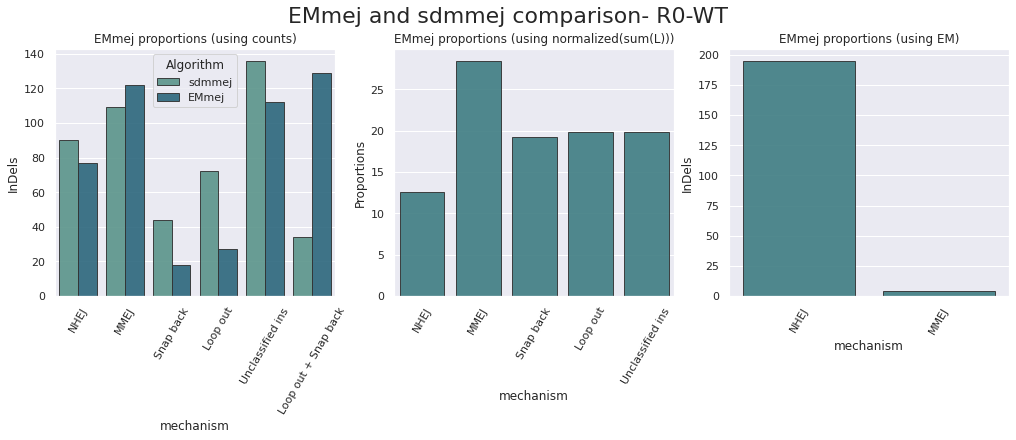

In [404]:
EMmej_input_tsv_path = '/home/labs/alevy/guyta/guy_master_project/results/Drosophila/Terrence_Hanscom_NAR_2022/sdmmej_EMmej_comparison/sdmmej_output_to_EMmej_input/R0_WT/20221008/20221008_R0_WT_sdmmej_output_EMmej_input.tsv'
file_prefix = '1737_20221008_20221008'
RMdetector_output = f'{EMmej_output_path}/{file_prefix}_R0_WT_sdmmej_output_EMmej_input_EMmej_run/output_files/RMdetector_output.tsv' 
ins_repair_proportions = f'{EMmej_output_path}/{file_prefix}_R0_WT_sdmmej_output_EMmej_input_EMmej_run/output_files/mechanism_proportion_insertions.tsv' 
del_repair_proportions = f'{EMmej_output_path}/{file_prefix}_R0_WT_sdmmej_output_EMmej_input_EMmej_run/output_files/20221008_EM_log.tsv' 
path_to_MM_output = f'{EMmej_output_path}/{file_prefix}_R0_WT_sdmmej_output_EMmej_input_EMmej_run/output_files/MM_output.tsv' 

EMmej_input_tsv = pd.read_csv(EMmej_input_tsv_path, sep='\t')

emmej_res = pd.read_csv(RMdetector_output, sep='\t')
MM_output = pd.read_csv(path_to_MM_output, sep='\t')
EMmej_RM_MM = emmej_res.join(MM_output, rsuffix='_MM')
EMmej_RM_MM.drop(columns = ['CHR_MM', 'POS_MM',
       'original_pos_MM', 'variant_id_MM', 'direction_MM',
       'ancestral_indel_MM', 'derived_indel_MM'], inplace=True)
EMmej_RM_MM
# Merging the EMmej and sdmmej results
emmej_sdmmej_merged = EMmej_RM_MM.merge(EMmej_input_tsv, left_on='CHR', right_on='#CHR')
emmej_sdmmej_merged.drop(columns=['REF', 'ALT', 'ID'], inplace=True)
emmej_sdmmej_merged.loc[(emmej_sdmmej_merged['del_mmej'] == True), :].shape
emmej_sdmmej_merged


"""
EMmej results: discrete meassuring (counting mechanisms using the boolian indications)
"""
# Deletions:
# making a list of cases of which del MMEJ was detected on at list one direction
mmej = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'DEL') & (emmej_sdmmej_merged['del_mmej'] == True)), 'CHR'].unique().tolist()

EMmej_nhej = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'DEL') & 
                         (emmej_sdmmej_merged['del_mmej'] == False) & 
                        (~emmej_sdmmej_merged['CHR'].isin(mmej))), :]
EMmej_nhej_count = EMmej_nhej['CHR'].unique().shape[0]

EMmej_mmej = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'DEL') & 
                         (emmej_sdmmej_merged['del_mmej'] == True) & 
                        (emmej_sdmmej_merged['CHR'].isin(mmej))), :]
EMmej_mmej_count = EMmej_mmej['CHR'].unique().shape[0]

# Insertions
# Snap back
snap = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'INS') & (emmej_sdmmej_merged['SD_snap_back'] == True)), 'CHR'].unique().tolist()
loop = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'INS') & (emmej_sdmmej_merged['SD_loop_out'] == True)), 'CHR'].unique().tolist()
EMmej_snap = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'INS') & 
                         (emmej_sdmmej_merged['SD_snap_back'] == True) & 
                        (emmej_sdmmej_merged['CHR'].isin(snap))), :]

EMmej_snap_count = EMmej_snap['CHR'].unique().shape[0]
EMmej_snap_count = len(parallel(snap,loop))
# Loop out
EMmej_loop = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'INS') & 
                         (emmej_sdmmej_merged['SD_loop_out'] == True) & 
                        (emmej_sdmmej_merged['CHR'].isin(loop))), :]
EMmej_loop_count = EMmej_snap['CHR'].unique().shape[0]
EMmej_loop_count = len(parallel(loop, snap))

# SD-MMEJ (Snap + Loop)
EMmej_snap_loop = pd.concat([EMmej_snap, EMmej_loop], axis=0)
EMmej_snap_loop_count = EMmej_snap_loop['CHR'].unique().shape[0]
EMmej_snap_loop_count = len(intersection(snap, loop))

# Unclassifed insertions
EMmej_unclassified_ins = emmej_sdmmej_merged.loc[((~emmej_sdmmej_merged['CHR'].isin(EMmej_snap_loop['CHR'].unique())) & (emmej_sdmmej_merged['indel_type'] == 'INS')),:]
EMmej_unclassified_ins_count = EMmej_unclassified_ins['CHR'].unique().shape[0]

# Getting EMmej repair mechanisms proportions based on probebalistic model and EM
# Insertions
ins_proportions = pd.read_csv(ins_repair_proportions, sep='\t')

"""
EMmej results: Estimating quantities of each mechanism.
    For deletions: quantities are given by EM estimations * number of deletions
    For insertions: quantities are given by summing the whole lk columns, normalizing them
        to get proportions and then * number of insertions
"""
# Insertions
likeliest_ins = get_likelier_mechanism(df=emmej_sdmmej_merged.loc[(emmej_sdmmej_merged['indel_type'] == 'INS'),:])
EMmej_snap_estimation = likeliest_ins.loc[(likeliest_ins['likeliest_mechanism'] == 'SD_snap_back_lk'),'SD_snap_back_lk'].sum()
EMmej_loop_estimation = likeliest_ins.loc[(likeliest_ins['likeliest_mechanism'] == 'SD_loop_out_lk'),'SD_loop_out_lk'].sum()
EMmej_SDMMEJ_estimation = EMmej_snap_estimation + EMmej_loop_estimation
EMmej_unclassified_ins_estimation = likeliest_ins.loc[(likeliest_ins['likeliest_mechanism'] == 'unclassified_ins_lk'),'unclassified_ins_lk'].sum()

snap_sum = emmej_sdmmej_merged.loc[(emmej_sdmmej_merged['indel_type'] == 'INS'),'SD_snap_back_lk'].sum()
loop_sum = emmej_sdmmej_merged.loc[(emmej_sdmmej_merged['indel_type'] == 'INS'),'SD_loop_out_lk'].sum()
Unclassified_ins_sum = emmej_sdmmej_merged.loc[(emmej_sdmmej_merged['indel_type'] == 'INS'),'unclassified_ins_lk'].sum()
ins_n = emmej_sdmmej_merged.loc[(emmej_sdmmej_merged['indel_type'] == 'INS'), 'CHR'].unique().shape[0]
norm_snap_sum = (snap_sum/(snap_sum+loop_sum+Unclassified_ins_sum))*ins_n
norm_loop_sum = (loop_sum/(snap_sum+loop_sum+Unclassified_ins_sum))*ins_n
norm_Unclassified_ins_sum = (Unclassified_ins_sum/(snap_sum+loop_sum+Unclassified_ins_sum))*ins_n

# Deletions using EM
del_proportions = pd.read_csv(del_repair_proportions, sep='\t')
EMmej_mmej_proportion = del_proportions.loc[del_proportions.index.max(), 'MMEJ_theta'] * emmej_sdmmej_merged.loc[emmej_sdmmej_merged['indel_type'] == 'DEL', 'CHR'].unique().shape[0]
EMmej_nhej_proportion = del_proportions.loc[del_proportions.index.max(), 'NHEJ_theta'] * emmej_sdmmej_merged.loc[emmej_sdmmej_merged['indel_type'] == 'DEL', 'CHR'].unique().shape[0]

# Deletions using sum of lk
del_n = emmej_sdmmej_merged.loc[emmej_sdmmej_merged['indel_type'] == 'DEL','CHR'].unique().shape[0]
mmej_lk_sum = emmej_sdmmej_merged.loc[emmej_sdmmej_merged['indel_type'] == 'DEL', 'del_mmej_lk'].sum()
nhej_lk_sum = emmej_sdmmej_merged.loc[emmej_sdmmej_merged['indel_type'] == 'DEL', 'NHEJ_lk'].sum()
norm_mmej_lk_sum = (mmej_lk_sum/(mmej_lk_sum+nhej_lk_sum))*del_n
norm_nhej_lk_sum = (nhej_lk_sum/(mmej_lk_sum+nhej_lk_sum))*del_n

"""
sdmmej results:
"""
# Deletions
sdmmej_Consistent_MHJ_reads = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'DEL') & 
                                             (emmej_sdmmej_merged['REPAIR_TYPE'] == 'MHJ') &
                                             (emmej_sdmmej_merged['consistency'] == True)), 'CHR'].unique().shape[0]
sdmmej_MMEJ_reads = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'DEL') & 
                                             (emmej_sdmmej_merged['REPAIR_TYPE'] == 'MHJ') &
                                             (emmej_sdmmej_merged['consistency'] == False)), 'CHR'].unique().shape[0]

sdmmej_mmej_reads = sdmmej_Consistent_MHJ_reads + sdmmej_MMEJ_reads

sdmmej_Consistent_ABJ_reads = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'DEL') & 
                                             (emmej_sdmmej_merged['REPAIR_TYPE'] == 'ABJ') &
                                             (emmej_sdmmej_merged['consistency'] == True)), 'CHR'].unique().shape[0]
sdmmej_NHEJ_reads = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'DEL') & 
                                             (emmej_sdmmej_merged['REPAIR_TYPE'] == 'ABJ') &
                                             (emmej_sdmmej_merged['consistency'] == False)), 'CHR'].unique().shape[0]

sdmmej_nhej_abj_reads = sdmmej_Consistent_ABJ_reads + sdmmej_NHEJ_reads

# Insertions
emmej_sdmmej_merged['SDMMEJ_snap'] = False
emmej_sdmmej_merged['SDMMEJ_loop'] = False
emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['Snap-back'] !='0') & (emmej_sdmmej_merged['Snap-back'].isna() == False)), 'SDMMEJ_snap'] = True
emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['Loop-out'] !='0') & (emmej_sdmmej_merged['Loop-out'].isna() == False)), 'SDMMEJ_loop'] = True

SDMMEJ_snap_reads = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['SDMMEJ_snap'] == True) & 
                                             (emmej_sdmmej_merged['indel_type'] == 'INS')), 'CHR'].unique().shape[0]
SDMMEJ_loop_reads = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['SDMMEJ_loop'] == True) & 
                                             (emmej_sdmmej_merged['indel_type'] == 'INS')), 'CHR'].unique().shape[0]


SDMMEJ_snap = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'INS') & (emmej_sdmmej_merged['SDMMEJ_snap'] == True)), 'CHR'].unique().tolist()
SDMMEJ_loop = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'INS') & (emmej_sdmmej_merged['SDMMEJ_loop'] == True)), 'CHR'].unique().tolist()
SDMMEJ_snap_count = len(parallel(SDMMEJ_snap, SDMMEJ_loop))
SDMMEJ_loop_count = len(parallel(SDMMEJ_loop, SDMMEJ_snap))
SDMMEJ_loop_and_loop_count = len(intersection(SDMMEJ_loop, SDMMEJ_snap))
# SDMMEJ_InDels_reads = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['mechanism'] == 'SDMMEJ_InDels') & (emmej_sdmmej_merged['indel_type'] == 'INS')), 'CHR'].unique().shape[0]
# Other_InDels_reads = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['mechanism'] == 'Other_InDels') & (emmej_sdmmej_merged['indel_type'] == 'INS')), 'CHR'].unique().shape[0]


indel_n = emmej_sdmmej_merged['CHR'].unique().shape[0]

mechanism_proportion = pd.DataFrame(columns=['mechanism','indel_type', 'Algorithm', 'InDels','Proportions'])

mechanism_proportion.loc[0,:] = 'NHEJ', 'Deletion', 'sdmmej' , sdmmej_nhej_abj_reads, np.nan
mechanism_proportion.loc[1,:] = 'NHEJ', 'Deletion', 'EMmej' , EMmej_nhej_count, np.nan
mechanism_proportion.loc[2,:] = 'NHEJ', 'Deletion', 'EMmej proportions estimation (EM)' , EMmej_nhej_proportion, np.nan
mechanism_proportion.loc[3,:] = 'NHEJ', 'Deletion', 'EMmej proportions estimation (sum(L))' , norm_mmej_lk_sum, (norm_mmej_lk_sum/indel_n)*100

mechanism_proportion.loc[4,:] = 'MMEJ', 'Deletion', 'sdmmej' , sdmmej_mmej_reads, np.nan
mechanism_proportion.loc[5,:] = 'MMEJ', 'Deletion', 'EMmej' , EMmej_mmej_count, np.nan
mechanism_proportion.loc[6,:] = 'MMEJ', 'Deletion', 'EMmej proportions estimation (EM)' , EMmej_mmej_proportion, np.nan
mechanism_proportion.loc[7,:] = 'MMEJ', 'Deletion', 'EMmej proportions estimation (sum(L))' , norm_nhej_lk_sum, (norm_nhej_lk_sum/indel_n)*100

# mechanism_proportion.loc[6,:] = 'SDMMEJ_Snap_back', 'Insertion', 'sdmmej' , SDMMEJ_snap_reads
mechanism_proportion.loc[8,:] = 'Snap back', 'Insertion', 'sdmmej' , SDMMEJ_snap_count, np.nan
# mechanism_proportion.loc[7,:] = 'SDMMEJ_Snap_back', 'Insertion', 'EMmej', likeliest_ins.loc[likeliest_ins['likeliest_mechanism'] == 'SD_snap_back_lk', 'CHR'].unique().shape[0]
mechanism_proportion.loc[9,:] = 'Snap back', 'Insertion', 'EMmej', EMmej_snap_count, np.nan
# mechanism_proportion.loc[8,:] = 'Snap back', 'Insertion', 'EMmej proportions estimation' , EMmej_snap_estimation
mechanism_proportion.loc[10,:] = 'Snap back', 'Insertion', 'EMmej proportions estimation (sum(L))' , norm_snap_sum, (norm_snap_sum/indel_n)*100


# mechanism_proportion.loc[9,:] = 'SDMMEJ_Loop_out', 'Insertion', 'sdmmej' , SDMMEJ_loop_reads
mechanism_proportion.loc[11,:] = 'Loop out', 'Insertion', 'sdmmej' , SDMMEJ_loop_count, np.nan
# mechanism_proportion.loc[10,:] = 'SDMMEJ_Loop_out', 'Insertion', 'EMmej', likeliest_ins.loc[likeliest_ins['likeliest_mechanism'] == 'SD_loop_out_lk', 'CHR'].unique().shape[0]
mechanism_proportion.loc[12,:] = 'Loop out', 'Insertion', 'EMmej', EMmej_loop_count, np.nan
# mechanism_proportion.loc[11,:] = 'Loop out', 'Insertion', 'EMmej proportions estimation' , EMmej_loop_estimation
mechanism_proportion.loc[13,:] = 'Loop out', 'Insertion', 'EMmej proportions estimation (sum(L))' , norm_loop_sum, (norm_loop_sum/indel_n)*100

mechanism_proportion.loc[14,:] = 'Unclassified ins', 'Insertion', 'sdmmej' , emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'INS') &
                                                                                                      (emmej_sdmmej_merged['SDMMEJ_loop'] == False) &
                                                                                                      (emmej_sdmmej_merged['SDMMEJ_snap'] == False)), 'CHR'].unique().shape[0], np.nan
mechanism_proportion.loc[15,:] = 'Unclassified ins', 'Insertion', 'EMmej' , emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'INS') & 
                                                             (~emmej_sdmmej_merged['CHR'].isin(snap+loop))),'CHR'].unique().shape[0], np.nan

mechanism_proportion.loc[16,:] = 'Unclassified ins', 'Insertion', 'EMmej proportions estimation (sum(L))',  norm_Unclassified_ins_sum, (norm_Unclassified_ins_sum/indel_n)*100


mechanism_proportion.loc[17,:] = 'Loop out + Snap back', 'Insertion', 'sdmmej' , SDMMEJ_loop_and_loop_count, np.nan
mechanism_proportion.loc[18,:] = 'Loop out + Snap back', 'Insertion', 'EMmej' , EMmej_snap_loop_count, np.nan


print(mechanism_proportion)


"""
Visualization
"""
# plt.figure(figsize = (7,5), dpi=80)
# ax = sns.barplot(data=mechanism_proportion,
#                  y='InDels', x='mechanism', hue='Algorithm', 
#                  palette="crest", alpha = 0.9, linewidth=1, edgecolor=".2")
# ax.set(title='EMmej and sdmmej comparison- R0-WT')
# plt.xticks(rotation = 45)
# # plt.text(x=3.55,y=1,s = 'EMmej:\n-MMEJ: MMEJ\n-NHEJ: NHEJ\n-SDMMEJ_InDels: SD-snap back + SD-loop out\n-Other_InDels: Unclassified insertions\n\nsdmmej:\n-MMEJ: MMEJ+Consistent_MHJ\n-NHEJ: NHEJ+Consistent_ABJ\n-SDMMEJ_InDels: SDMMEJ_InDels\n-Other_InDels: Other_InDels')
# # plt.show()
# fig = ax.get_figure()

# fig.savefig(f"{path_to_save_plots}/1141_20221001_EMmej_150bp_sdmmej_comparison_R0_WT.svg", bbox_inches='tight')


fig, (ax1, ax2, ax3) = plt.subplots(1,3,figsize=(14, 6), constrained_layout=True, sharey=False)
# NHEJ
fig.suptitle('EMmej and sdmmej comparison- R0-WT', fontsize=22)

ax1 = sns.barplot(data=mechanism_proportion.loc[mechanism_proportion['Algorithm'].isin(['sdmmej', 'EMmej']), :],
                 y='InDels', x='mechanism', hue='Algorithm', 
                 palette="crest", alpha = 0.9, linewidth=1, edgecolor=".2", ax=ax1)
ax1.set(title='EMmej proportions (using counts)')
ax1.set_xticklabels(
    ax1.get_xticklabels(), 
    rotation=60)

ax2 = sns.barplot(data=mechanism_proportion.loc[mechanism_proportion['Algorithm'].isin(['EMmej proportions estimation (sum(L))']), :],
                 y='Proportions', x='mechanism', hue='Algorithm', 
                 palette="crest", alpha = 0.9, linewidth=1, edgecolor=".2", ax=ax2)
ax2.legend([],[], frameon=False)
ax2.set(title='EMmej proportions (using normalized(sum(L)))')
ax2.set_xticklabels(
    ax2.get_xticklabels(), 
    rotation=60)
# ax2 = mechanism_proportion.loc[
#     mechanism_proportion['Algorithm'].isin(['EMmej proportions estimation (sum(L))']), 
#     ['Proportions', 'mechanism']].set_index('mechanism').T.plot(kind='bar',
#                                             stacked=True, width=0.3, ax=ax2)

# ax2.set_xticklabels(
#     ax2.get_xticklabels(), 
#     rotation=60)
# ax2.set(xlabel=None, ylabel='Proportions [%]')
# # plt.xticks(color='w')
# ax2.set(title='EMmej proportions (using normalized(sum(L)))')
# ax2.legend(bbox_to_anchor=(1, 1))

ax3 = sns.barplot(data=mechanism_proportion.loc[mechanism_proportion['Algorithm'].isin(['EMmej proportions estimation (EM)']), :],
                 y='InDels', x='mechanism', hue='Algorithm', 
                 palette="crest", alpha = 0.9, linewidth=1, edgecolor=".2", ax=ax3)
ax3.legend([],[], frameon=False)
ax3.set(title='EMmej proportions (using EM)')
ax3.set_xticklabels(
    ax3.get_xticklabels(), 
    rotation=60)

print(mechanism_proportion.loc[((mechanism_proportion['indel_type'] == 'Insertion') & (mechanism_proportion['Algorithm'] == 'sdmmej')), :].sum())
print(mechanism_proportion.loc[((mechanism_proportion['indel_type'] == 'Insertion') & (mechanism_proportion['Algorithm'] == 'EMmej')), :].sum())


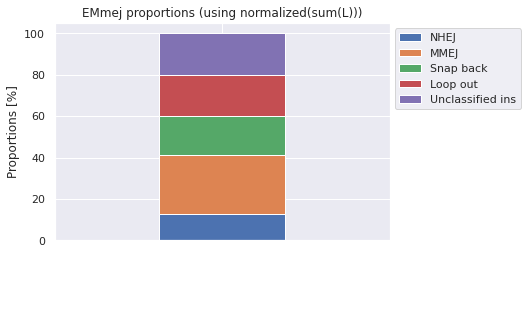

In [257]:
ax = mechanism_proportion.loc[
    mechanism_proportion['Algorithm'].isin(['EMmej proportions estimation (sum(L))']), 
    ['Proportions', 'mechanism']].set_index('mechanism').T.plot(kind='bar',
                                            stacked=True, width=0.3)
ax.set(xlabel=None, ylabel='Proportions [%]')
plt.xticks(color='w')
ax.set(title='EMmej proportions (using normalized(sum(L)))')
ax.legend(bbox_to_anchor=(1, 1))

In [385]:
len('GCGGCCGCATAGGCCACTAGTGGATCTGGATCCTCTAGAGTCGACCTCGAACGTTAACGTTAACGTAACGTTAACTCGAGGCCCTGATAATAATTAATTAAGACGTCAGAATTCTCGAGGCGGCCGCATGTGCGTCTCCCTATAGTGAGTCGTATTAATTTCGCGGGCGGAACCCCTATTTGTTTATTTTTCTAAATACATTCAAATATGTATCCGCTCATGAGACAATAACCCTGATAAATGCTTCAATAATATTGAAAAAGGAAGAGTATGAGTATTC')

280

In [403]:
emmej_sdmmej_merged.loc[(emmej_sdmmej_merged['SD_loop_out']), ['direction','loop_repeat_pat','loop_mmej_marked', 'Loop-out', 'snap_repeat_pat', 'snap_mmej_marked','snap_inv_comp_repeat_pat','Snap-back']].iloc[10:20, :]
1*10**7

10000000

# R0_POLQ

               mechanism indel_type                              Algorithm  \
0                   NHEJ   Deletion                                 sdmmej   
1                   NHEJ   Deletion                                  EMmej   
2                   NHEJ   Deletion      EMmej proportions estimation (EM)   
3                   NHEJ   Deletion  EMmej proportions estimation (sum(L))   
4                   MMEJ   Deletion                                 sdmmej   
5                   MMEJ   Deletion                                  EMmej   
6                   MMEJ   Deletion      EMmej proportions estimation (EM)   
7                   MMEJ   Deletion  EMmej proportions estimation (sum(L))   
8              Snap back  Insertion                                 sdmmej   
9              Snap back  Insertion                                  EMmej   
10             Snap back  Insertion  EMmej proportions estimation (sum(L))   
11              Loop out  Insertion                             

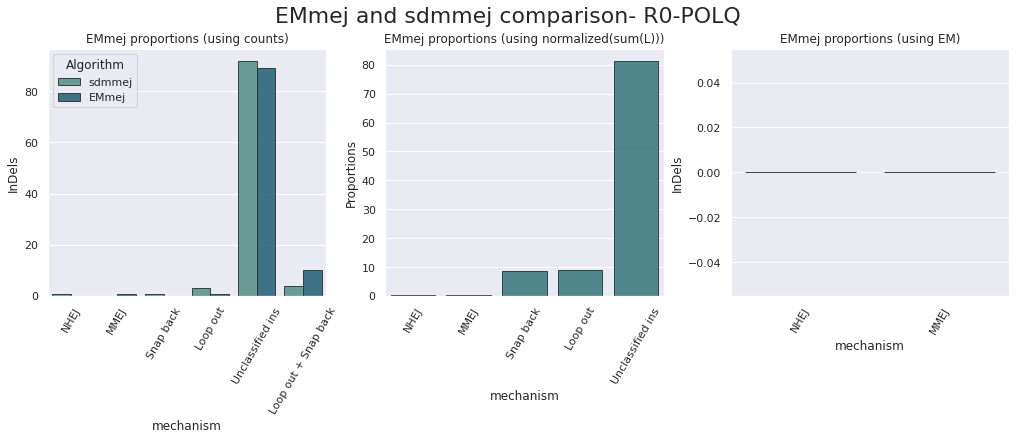

In [415]:
EMmej_input_tsv_path = '/home/labs/alevy/guyta/guy_master_project/results/Drosophila/Terrence_Hanscom_NAR_2022/sdmmej_EMmej_comparison/sdmmej_output_to_EMmej_input/R0_POLQ/20221008/20221008_R0_POLQ_sdmmej_output_EMmej_input.tsv'
file_prefix = '1737_20221008_20221008'
RMdetector_output = f'{EMmej_output_path}/{file_prefix}_R0_POLQ_sdmmej_output_EMmej_input_EMmej_run/output_files/RMdetector_output.tsv' 
ins_repair_proportions = f'{EMmej_output_path}/{file_prefix}_R0_POLQ_sdmmej_output_EMmej_input_EMmej_run/output_files/mechanism_proportion_insertions.tsv' 
del_repair_proportions = f'{EMmej_output_path}/{file_prefix}_R0_POLQ_sdmmej_output_EMmej_input_EMmej_run/output_files/20221008_EM_log.tsv' 
path_to_MM_output = f'{EMmej_output_path}/{file_prefix}_R0_POLQ_sdmmej_output_EMmej_input_EMmej_run/output_files/MM_output.tsv' 

EMmej_input_tsv = pd.read_csv(EMmej_input_tsv_path, sep='\t')

emmej_res = pd.read_csv(RMdetector_output, sep='\t')
MM_output = pd.read_csv(path_to_MM_output, sep='\t')
EMmej_RM_MM = emmej_res.join(MM_output, rsuffix='_MM')
EMmej_RM_MM.drop(columns = ['CHR_MM', 'POS_MM',
       'original_pos_MM', 'variant_id_MM', 'direction_MM',
       'ancestral_indel_MM', 'derived_indel_MM'], inplace=True)
EMmej_RM_MM
# Merging the EMmej and sdmmej results
emmej_sdmmej_merged = EMmej_RM_MM.merge(EMmej_input_tsv, left_on='CHR', right_on='#CHR')
emmej_sdmmej_merged.drop(columns=['REF', 'ALT', 'ID'], inplace=True)
emmej_sdmmej_merged.loc[(emmej_sdmmej_merged['del_mmej'] == True), :].shape
emmej_sdmmej_merged


"""
EMmej results: discrete meassuring (counting mechanisms using the boolian indications)
"""
# Deletions:
# making a list of cases of which del MMEJ was detected on at list one direction
mmej = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'DEL') & (emmej_sdmmej_merged['del_mmej'] == True)), 'CHR'].unique().tolist()

EMmej_nhej = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'DEL') & 
                         (emmej_sdmmej_merged['del_mmej'] == False) & 
                        (~emmej_sdmmej_merged['CHR'].isin(mmej))), :]
EMmej_nhej_count = EMmej_nhej['CHR'].unique().shape[0]

EMmej_mmej = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'DEL') & 
                         (emmej_sdmmej_merged['del_mmej'] == True) & 
                        (emmej_sdmmej_merged['CHR'].isin(mmej))), :]
EMmej_mmej_count = EMmej_mmej['CHR'].unique().shape[0]

# Insertions
# Snap back
snap = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'INS') & (emmej_sdmmej_merged['SD_snap_back'] == True)), 'CHR'].unique().tolist()
loop = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'INS') & (emmej_sdmmej_merged['SD_loop_out'] == True)), 'CHR'].unique().tolist()
EMmej_snap = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'INS') & 
                         (emmej_sdmmej_merged['SD_snap_back'] == True) & 
                        (emmej_sdmmej_merged['CHR'].isin(snap))), :]

EMmej_snap_count = EMmej_snap['CHR'].unique().shape[0]
EMmej_snap_count = len(parallel(snap,loop))
# Loop out
EMmej_loop = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'INS') & 
                         (emmej_sdmmej_merged['SD_loop_out'] == True) & 
                        (emmej_sdmmej_merged['CHR'].isin(loop))), :]
EMmej_loop_count = EMmej_snap['CHR'].unique().shape[0]
EMmej_loop_count = len(parallel(loop, snap))

# SD-MMEJ (Snap + Loop)
EMmej_snap_loop = pd.concat([EMmej_snap, EMmej_loop], axis=0)
EMmej_snap_loop_count = EMmej_snap_loop['CHR'].unique().shape[0]
EMmej_snap_loop_count = len(intersection(snap, loop))

# Unclassifed insertions
EMmej_unclassified_ins = emmej_sdmmej_merged.loc[((~emmej_sdmmej_merged['CHR'].isin(EMmej_snap_loop['CHR'].unique())) & (emmej_sdmmej_merged['indel_type'] == 'INS')),:]
EMmej_unclassified_ins_count = EMmej_unclassified_ins['CHR'].unique().shape[0]

# Getting EMmej repair mechanisms proportions based on probebalistic model and EM
# Insertions
ins_proportions = pd.read_csv(ins_repair_proportions, sep='\t')

"""
EMmej results: Estimating quantities of each mechanism.
    For deletions: quantities are given by EM estimations * number of deletions
    For insertions: quantities are given by summing the whole lk columns, normalizing them
        to get proportions and then * number of insertions
"""
# Insertions
likeliest_ins = get_likelier_mechanism(df=emmej_sdmmej_merged.loc[(emmej_sdmmej_merged['indel_type'] == 'INS'),:])
EMmej_snap_estimation = likeliest_ins.loc[(likeliest_ins['likeliest_mechanism'] == 'SD_snap_back_lk'),'SD_snap_back_lk'].sum()
EMmej_loop_estimation = likeliest_ins.loc[(likeliest_ins['likeliest_mechanism'] == 'SD_loop_out_lk'),'SD_loop_out_lk'].sum()
EMmej_SDMMEJ_estimation = EMmej_snap_estimation + EMmej_loop_estimation
EMmej_unclassified_ins_estimation = likeliest_ins.loc[(likeliest_ins['likeliest_mechanism'] == 'unclassified_ins_lk'),'unclassified_ins_lk'].sum()

snap_sum = emmej_sdmmej_merged.loc[(emmej_sdmmej_merged['indel_type'] == 'INS'),'SD_snap_back_lk'].sum()
loop_sum = emmej_sdmmej_merged.loc[(emmej_sdmmej_merged['indel_type'] == 'INS'),'SD_loop_out_lk'].sum()
Unclassified_ins_sum = emmej_sdmmej_merged.loc[(emmej_sdmmej_merged['indel_type'] == 'INS'),'unclassified_ins_lk'].sum()
ins_n = emmej_sdmmej_merged.loc[(emmej_sdmmej_merged['indel_type'] == 'INS'), 'CHR'].unique().shape[0]
norm_snap_sum = (snap_sum/(snap_sum+loop_sum+Unclassified_ins_sum))*ins_n
norm_loop_sum = (loop_sum/(snap_sum+loop_sum+Unclassified_ins_sum))*ins_n
norm_Unclassified_ins_sum = (Unclassified_ins_sum/(snap_sum+loop_sum+Unclassified_ins_sum))*ins_n

# Deletions using EM
del_proportions = pd.read_csv(del_repair_proportions, sep='\t')
EMmej_mmej_proportion = del_proportions.loc[del_proportions.index.max(), 'MMEJ_theta'] * emmej_sdmmej_merged.loc[emmej_sdmmej_merged['indel_type'] == 'DEL', 'CHR'].unique().shape[0]
EMmej_nhej_proportion = del_proportions.loc[del_proportions.index.max(), 'NHEJ_theta'] * emmej_sdmmej_merged.loc[emmej_sdmmej_merged['indel_type'] == 'DEL', 'CHR'].unique().shape[0]

# Deletions using sum of lk
del_n = emmej_sdmmej_merged.loc[emmej_sdmmej_merged['indel_type'] == 'DEL','CHR'].unique().shape[0]
mmej_lk_sum = emmej_sdmmej_merged.loc[emmej_sdmmej_merged['indel_type'] == 'DEL', 'del_mmej_lk'].sum()
nhej_lk_sum = emmej_sdmmej_merged.loc[emmej_sdmmej_merged['indel_type'] == 'DEL', 'NHEJ_lk'].sum()
norm_mmej_lk_sum = (mmej_lk_sum/(mmej_lk_sum+nhej_lk_sum))*del_n
norm_nhej_lk_sum = (nhej_lk_sum/(mmej_lk_sum+nhej_lk_sum))*del_n

"""
sdmmej results:
"""
# Deletions
sdmmej_Consistent_MHJ_reads = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'DEL') & 
                                             (emmej_sdmmej_merged['REPAIR_TYPE'] == 'MHJ') &
                                             (emmej_sdmmej_merged['consistency'] == True)), 'CHR'].unique().shape[0]
sdmmej_MMEJ_reads = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'DEL') & 
                                             (emmej_sdmmej_merged['REPAIR_TYPE'] == 'MHJ') &
                                             (emmej_sdmmej_merged['consistency'] == False)), 'CHR'].unique().shape[0]

sdmmej_mmej_reads = sdmmej_Consistent_MHJ_reads + sdmmej_MMEJ_reads

sdmmej_Consistent_ABJ_reads = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'DEL') & 
                                             (emmej_sdmmej_merged['REPAIR_TYPE'] == 'ABJ') &
                                             (emmej_sdmmej_merged['consistency'] == True)), 'CHR'].unique().shape[0]
sdmmej_NHEJ_reads = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'DEL') & 
                                             (emmej_sdmmej_merged['REPAIR_TYPE'] == 'ABJ') &
                                             (emmej_sdmmej_merged['consistency'] == False)), 'CHR'].unique().shape[0]

sdmmej_nhej_abj_reads = sdmmej_Consistent_ABJ_reads + sdmmej_NHEJ_reads

# Insertions
emmej_sdmmej_merged['SDMMEJ_snap'] = False
emmej_sdmmej_merged['SDMMEJ_loop'] = False
emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['Snap-back'] !='0') & (emmej_sdmmej_merged['Snap-back'].isna() == False)), 'SDMMEJ_snap'] = True
emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['Loop-out'] !='0') & (emmej_sdmmej_merged['Loop-out'].isna() == False)), 'SDMMEJ_loop'] = True

SDMMEJ_snap_reads = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['SDMMEJ_snap'] == True) & 
                                             (emmej_sdmmej_merged['indel_type'] == 'INS')), 'CHR'].unique().shape[0]
SDMMEJ_loop_reads = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['SDMMEJ_loop'] == True) & 
                                             (emmej_sdmmej_merged['indel_type'] == 'INS')), 'CHR'].unique().shape[0]


SDMMEJ_snap = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'INS') & (emmej_sdmmej_merged['SDMMEJ_snap'] == True)), 'CHR'].unique().tolist()
SDMMEJ_loop = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'INS') & (emmej_sdmmej_merged['SDMMEJ_loop'] == True)), 'CHR'].unique().tolist()
SDMMEJ_snap_count = len(parallel(SDMMEJ_snap, SDMMEJ_loop))
SDMMEJ_loop_count = len(parallel(SDMMEJ_loop, SDMMEJ_snap))
SDMMEJ_loop_and_loop_count = len(intersection(SDMMEJ_loop, SDMMEJ_snap))
# SDMMEJ_InDels_reads = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['mechanism'] == 'SDMMEJ_InDels') & (emmej_sdmmej_merged['indel_type'] == 'INS')), 'CHR'].unique().shape[0]
# Other_InDels_reads = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['mechanism'] == 'Other_InDels') & (emmej_sdmmej_merged['indel_type'] == 'INS')), 'CHR'].unique().shape[0]


indel_n = emmej_sdmmej_merged['CHR'].unique().shape[0]

mechanism_proportion = pd.DataFrame(columns=['mechanism','indel_type', 'Algorithm', 'InDels','Proportions'])

mechanism_proportion.loc[0,:] = 'NHEJ', 'Deletion', 'sdmmej' , sdmmej_nhej_abj_reads, np.nan
mechanism_proportion.loc[1,:] = 'NHEJ', 'Deletion', 'EMmej' , EMmej_nhej_count, np.nan
mechanism_proportion.loc[2,:] = 'NHEJ', 'Deletion', 'EMmej proportions estimation (EM)' , EMmej_nhej_proportion, np.nan
mechanism_proportion.loc[3,:] = 'NHEJ', 'Deletion', 'EMmej proportions estimation (sum(L))' , norm_mmej_lk_sum, (norm_mmej_lk_sum/indel_n)*100

mechanism_proportion.loc[4,:] = 'MMEJ', 'Deletion', 'sdmmej' , sdmmej_mmej_reads, np.nan
mechanism_proportion.loc[5,:] = 'MMEJ', 'Deletion', 'EMmej' , EMmej_mmej_count, np.nan
mechanism_proportion.loc[6,:] = 'MMEJ', 'Deletion', 'EMmej proportions estimation (EM)' , EMmej_mmej_proportion, np.nan
mechanism_proportion.loc[7,:] = 'MMEJ', 'Deletion', 'EMmej proportions estimation (sum(L))' , norm_nhej_lk_sum, (norm_nhej_lk_sum/indel_n)*100

# mechanism_proportion.loc[6,:] = 'SDMMEJ_Snap_back', 'Insertion', 'sdmmej' , SDMMEJ_snap_reads
mechanism_proportion.loc[8,:] = 'Snap back', 'Insertion', 'sdmmej' , SDMMEJ_snap_count, np.nan
# mechanism_proportion.loc[7,:] = 'SDMMEJ_Snap_back', 'Insertion', 'EMmej', likeliest_ins.loc[likeliest_ins['likeliest_mechanism'] == 'SD_snap_back_lk', 'CHR'].unique().shape[0]
mechanism_proportion.loc[9,:] = 'Snap back', 'Insertion', 'EMmej', EMmej_snap_count, np.nan
# mechanism_proportion.loc[8,:] = 'Snap back', 'Insertion', 'EMmej proportions estimation' , EMmej_snap_estimation
mechanism_proportion.loc[10,:] = 'Snap back', 'Insertion', 'EMmej proportions estimation (sum(L))' , norm_snap_sum, (norm_snap_sum/indel_n)*100


# mechanism_proportion.loc[9,:] = 'SDMMEJ_Loop_out', 'Insertion', 'sdmmej' , SDMMEJ_loop_reads
mechanism_proportion.loc[11,:] = 'Loop out', 'Insertion', 'sdmmej' , SDMMEJ_loop_count, np.nan
# mechanism_proportion.loc[10,:] = 'SDMMEJ_Loop_out', 'Insertion', 'EMmej', likeliest_ins.loc[likeliest_ins['likeliest_mechanism'] == 'SD_loop_out_lk', 'CHR'].unique().shape[0]
mechanism_proportion.loc[12,:] = 'Loop out', 'Insertion', 'EMmej', EMmej_loop_count, np.nan
# mechanism_proportion.loc[11,:] = 'Loop out', 'Insertion', 'EMmej proportions estimation' , EMmej_loop_estimation
mechanism_proportion.loc[13,:] = 'Loop out', 'Insertion', 'EMmej proportions estimation (sum(L))' , norm_loop_sum, (norm_loop_sum/indel_n)*100

mechanism_proportion.loc[14,:] = 'Unclassified ins', 'Insertion', 'sdmmej' , emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'INS') &
                                                                                                      (emmej_sdmmej_merged['SDMMEJ_loop'] == False) &
                                                                                                      (emmej_sdmmej_merged['SDMMEJ_snap'] == False)), 'CHR'].unique().shape[0], np.nan
mechanism_proportion.loc[15,:] = 'Unclassified ins', 'Insertion', 'EMmej' , emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'INS') & 
                                                             (~emmej_sdmmej_merged['CHR'].isin(snap+loop))),'CHR'].unique().shape[0], np.nan

mechanism_proportion.loc[16,:] = 'Unclassified ins', 'Insertion', 'EMmej proportions estimation (sum(L))',  norm_Unclassified_ins_sum, (norm_Unclassified_ins_sum/indel_n)*100


mechanism_proportion.loc[17,:] = 'Loop out + Snap back', 'Insertion', 'sdmmej' , SDMMEJ_loop_and_loop_count, np.nan
mechanism_proportion.loc[18,:] = 'Loop out + Snap back', 'Insertion', 'EMmej' , EMmej_snap_loop_count, np.nan


print(mechanism_proportion)


"""
Visualization
"""
# plt.figure(figsize = (7,5), dpi=80)
# ax = sns.barplot(data=mechanism_proportion,
#                  y='InDels', x='mechanism', hue='Algorithm', 
#                  palette="crest", alpha = 0.9, linewidth=1, edgecolor=".2")
# ax.set(title='EMmej and sdmmej comparison- R0-WT')
# plt.xticks(rotation = 45)
# # plt.text(x=3.55,y=1,s = 'EMmej:\n-MMEJ: MMEJ\n-NHEJ: NHEJ\n-SDMMEJ_InDels: SD-snap back + SD-loop out\n-Other_InDels: Unclassified insertions\n\nsdmmej:\n-MMEJ: MMEJ+Consistent_MHJ\n-NHEJ: NHEJ+Consistent_ABJ\n-SDMMEJ_InDels: SDMMEJ_InDels\n-Other_InDels: Other_InDels')
# # plt.show()
# fig = ax.get_figure()

# fig.savefig(f"{path_to_save_plots}/1141_20221001_EMmej_150bp_sdmmej_comparison_R0_POLQ.svg", bbox_inches='tight')


fig, (ax1, ax2, ax3) = plt.subplots(1,3,figsize=(14, 6), constrained_layout=True, sharey=False)
# NHEJ
fig.suptitle('EMmej and sdmmej comparison- R0-POLQ', fontsize=22)

ax1 = sns.barplot(data=mechanism_proportion.loc[mechanism_proportion['Algorithm'].isin(['sdmmej', 'EMmej']), :],
                 y='InDels', x='mechanism', hue='Algorithm', 
                 palette="crest", alpha = 0.9, linewidth=1, edgecolor=".2", ax=ax1)
ax1.set(title='EMmej proportions (using counts)')
ax1.set_xticklabels(
    ax1.get_xticklabels(), 
    rotation=60)

ax2 = sns.barplot(data=mechanism_proportion.loc[mechanism_proportion['Algorithm'].isin(['EMmej proportions estimation (sum(L))']), :],
                 y='Proportions', x='mechanism', hue='Algorithm', 
                 palette="crest", alpha = 0.9, linewidth=1, edgecolor=".2", ax=ax2)
ax2.legend([],[], frameon=False)
ax2.set(title='EMmej proportions (using normalized(sum(L)))')
ax2.set_xticklabels(
    ax2.get_xticklabels(), 
    rotation=60)
# ax2 = mechanism_proportion.loc[
#     mechanism_proportion['Algorithm'].isin(['EMmej proportions estimation (sum(L))']), 
#     ['Proportions', 'mechanism']].set_index('mechanism').T.plot(kind='bar',
#                                             stacked=True, width=0.3, ax=ax2)

# ax2.set_xticklabels(
#     ax2.get_xticklabels(), 
#     rotation=60)
# ax2.set(xlabel=None, ylabel='Proportions [%]')
# # plt.xticks(color='w')
# ax2.set(title='EMmej proportions (using normalized(sum(L)))')
# ax2.legend(bbox_to_anchor=(1, 1))

ax3 = sns.barplot(data=mechanism_proportion.loc[mechanism_proportion['Algorithm'].isin(['EMmej proportions estimation (EM)']), :],
                 y='InDels', x='mechanism', hue='Algorithm', 
                 palette="crest", alpha = 0.9, linewidth=1, edgecolor=".2", ax=ax3)
ax3.legend([],[], frameon=False)
ax3.set(title='EMmej proportions (using EM)')
ax3.set_xticklabels(
    ax3.get_xticklabels(), 
    rotation=60)

print(mechanism_proportion.loc[((mechanism_proportion['indel_type'] == 'Insertion') & (mechanism_proportion['Algorithm'] == 'sdmmej')), :].sum())
print(mechanism_proportion.loc[((mechanism_proportion['indel_type'] == 'Insertion') & (mechanism_proportion['Algorithm'] == 'EMmej')), :].sum())
print(emmej_sdmmej_merged.loc[emmej_sdmmej_merged['indel_type'] == 'INS', 'CHR'].unique().shape[0])

In [ ]:
emmej_sdmmej_merged.loc[(~emmej_sdmmej_merged['CHR'].duplicated()), 
                        'indel_type'].value_counts()


# R0_Lig4

DEL    51
INS    31
Name: indel_type, dtype: int64
               mechanism indel_type                              Algorithm  \
0                   NHEJ   Deletion                                 sdmmej   
1                   NHEJ   Deletion                                  EMmej   
2                   NHEJ   Deletion      EMmej proportions estimation (EM)   
3                   NHEJ   Deletion  EMmej proportions estimation (sum(L))   
4                   MMEJ   Deletion                                 sdmmej   
5                   MMEJ   Deletion                                  EMmej   
6                   MMEJ   Deletion      EMmej proportions estimation (EM)   
7                   MMEJ   Deletion  EMmej proportions estimation (sum(L))   
8              Snap back  Insertion                                 sdmmej   
9              Snap back  Insertion                                  EMmej   
10             Snap back  Insertion  EMmej proportions estimation (sum(L))   
11           

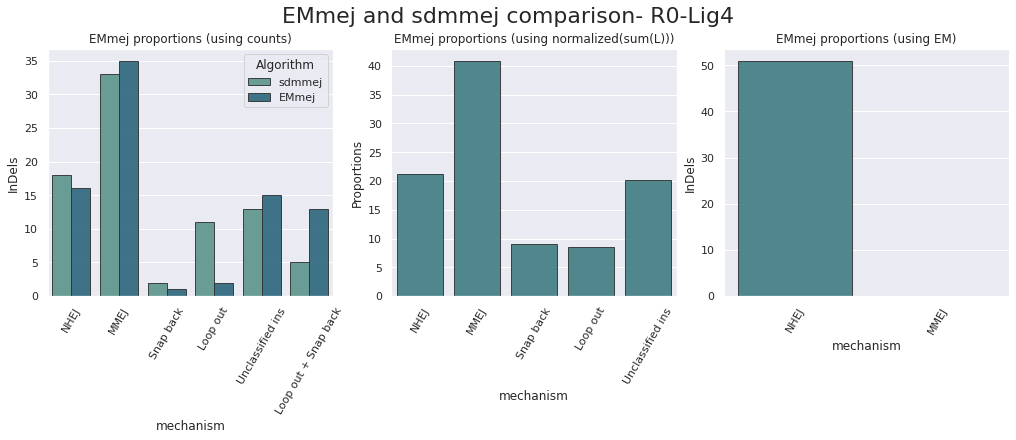

In [417]:
EMmej_input_tsv_path = '/home/labs/alevy/guyta/guy_master_project/results/Drosophila/Terrence_Hanscom_NAR_2022/sdmmej_EMmej_comparison/sdmmej_output_to_EMmej_input/R0_Lig4/20221008/20221008_R0_Lig4_sdmmej_output_EMmej_input.tsv'
file_prefix = '1737_20221008_20221008'
RMdetector_output = f'{EMmej_output_path}/{file_prefix}_R0_Lig4_sdmmej_output_EMmej_input_EMmej_run/output_files/RMdetector_output.tsv' 
ins_repair_proportions = f'{EMmej_output_path}/{file_prefix}_R0_Lig4_sdmmej_output_EMmej_input_EMmej_run/output_files/mechanism_proportion_insertions.tsv' 
del_repair_proportions = f'{EMmej_output_path}/{file_prefix}_R0_Lig4_sdmmej_output_EMmej_input_EMmej_run/output_files/20221008_EM_log.tsv' 
path_to_MM_output = f'{EMmej_output_path}/{file_prefix}_R0_Lig4_sdmmej_output_EMmej_input_EMmej_run/output_files/MM_output.tsv' 

EMmej_input_tsv = pd.read_csv(EMmej_input_tsv_path, sep='\t')

emmej_res = pd.read_csv(RMdetector_output, sep='\t')
MM_output = pd.read_csv(path_to_MM_output, sep='\t')
EMmej_RM_MM = emmej_res.join(MM_output, rsuffix='_MM')
EMmej_RM_MM.drop(columns = ['CHR_MM', 'POS_MM',
       'original_pos_MM', 'variant_id_MM', 'direction_MM',
       'ancestral_indel_MM', 'derived_indel_MM'], inplace=True)
EMmej_RM_MM
# Merging the EMmej and sdmmej results
emmej_sdmmej_merged = EMmej_RM_MM.merge(EMmej_input_tsv, left_on='CHR', right_on='#CHR')
emmej_sdmmej_merged.drop(columns=['REF', 'ALT', 'ID'], inplace=True)
emmej_sdmmej_merged.loc[(emmej_sdmmej_merged['del_mmej'] == True), :].shape
emmej_sdmmej_merged
print(emmej_sdmmej_merged.loc[(~emmej_sdmmej_merged['CHR'].duplicated()), 
                        'indel_type'].value_counts())

"""
EMmej results: discrete meassuring (counting mechanisms using the boolian indications)
"""
# Deletions:
# making a list of cases of which del MMEJ was detected on at list one direction
mmej = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'DEL') & (emmej_sdmmej_merged['del_mmej'] == True)), 'CHR'].unique().tolist()

EMmej_nhej = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'DEL') & 
                         (emmej_sdmmej_merged['del_mmej'] == False) & 
                        (~emmej_sdmmej_merged['CHR'].isin(mmej))), :]
EMmej_nhej_count = EMmej_nhej['CHR'].unique().shape[0]

EMmej_mmej = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'DEL') & 
                         (emmej_sdmmej_merged['del_mmej'] == True) & 
                        (emmej_sdmmej_merged['CHR'].isin(mmej))), :]
EMmej_mmej_count = EMmej_mmej['CHR'].unique().shape[0]

# Insertions
# Snap back
snap = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'INS') & (emmej_sdmmej_merged['SD_snap_back'] == True)), 'CHR'].unique().tolist()
loop = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'INS') & (emmej_sdmmej_merged['SD_loop_out'] == True)), 'CHR'].unique().tolist()
EMmej_snap = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'INS') & 
                         (emmej_sdmmej_merged['SD_snap_back'] == True) & 
                        (emmej_sdmmej_merged['CHR'].isin(snap))), :]

EMmej_snap_count = EMmej_snap['CHR'].unique().shape[0]
EMmej_snap_count = len(parallel(snap,loop))
# Loop out
EMmej_loop = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'INS') & 
                         (emmej_sdmmej_merged['SD_loop_out'] == True) & 
                        (emmej_sdmmej_merged['CHR'].isin(loop))), :]
EMmej_loop_count = EMmej_snap['CHR'].unique().shape[0]
EMmej_loop_count = len(parallel(loop, snap))

# SD-MMEJ (Snap + Loop)
EMmej_snap_loop = pd.concat([EMmej_snap, EMmej_loop], axis=0)
EMmej_snap_loop_count = EMmej_snap_loop['CHR'].unique().shape[0]
EMmej_snap_loop_count = len(intersection(snap, loop))

# Unclassifed insertions
EMmej_unclassified_ins = emmej_sdmmej_merged.loc[((~emmej_sdmmej_merged['CHR'].isin(EMmej_snap_loop['CHR'].unique())) & (emmej_sdmmej_merged['indel_type'] == 'INS')),:]
EMmej_unclassified_ins_count = EMmej_unclassified_ins['CHR'].unique().shape[0]

# Getting EMmej repair mechanisms proportions based on probebalistic model and EM
# Insertions
ins_proportions = pd.read_csv(ins_repair_proportions, sep='\t')

"""
EMmej results: Estimating quantities of each mechanism.
    For deletions: quantities are given by EM estimations * number of deletions
    For insertions: quantities are given by summing the whole lk columns, normalizing them
        to get proportions and then * number of insertions
"""
# Insertions
likeliest_ins = get_likelier_mechanism(df=emmej_sdmmej_merged.loc[(emmej_sdmmej_merged['indel_type'] == 'INS'),:])
EMmej_snap_estimation = likeliest_ins.loc[(likeliest_ins['likeliest_mechanism'] == 'SD_snap_back_lk'),'SD_snap_back_lk'].sum()
EMmej_loop_estimation = likeliest_ins.loc[(likeliest_ins['likeliest_mechanism'] == 'SD_loop_out_lk'),'SD_loop_out_lk'].sum()
EMmej_SDMMEJ_estimation = EMmej_snap_estimation + EMmej_loop_estimation
EMmej_unclassified_ins_estimation = likeliest_ins.loc[(likeliest_ins['likeliest_mechanism'] == 'unclassified_ins_lk'),'unclassified_ins_lk'].sum()

snap_sum = emmej_sdmmej_merged.loc[(emmej_sdmmej_merged['indel_type'] == 'INS'),'SD_snap_back_lk'].sum()
loop_sum = emmej_sdmmej_merged.loc[(emmej_sdmmej_merged['indel_type'] == 'INS'),'SD_loop_out_lk'].sum()
Unclassified_ins_sum = emmej_sdmmej_merged.loc[(emmej_sdmmej_merged['indel_type'] == 'INS'),'unclassified_ins_lk'].sum()
ins_n = emmej_sdmmej_merged.loc[(emmej_sdmmej_merged['indel_type'] == 'INS'), 'CHR'].unique().shape[0]
norm_snap_sum = (snap_sum/(snap_sum+loop_sum+Unclassified_ins_sum))*ins_n
norm_loop_sum = (loop_sum/(snap_sum+loop_sum+Unclassified_ins_sum))*ins_n
norm_Unclassified_ins_sum = (Unclassified_ins_sum/(snap_sum+loop_sum+Unclassified_ins_sum))*ins_n

# Deletions using EM
del_proportions = pd.read_csv(del_repair_proportions, sep='\t')
EMmej_mmej_proportion = del_proportions.loc[del_proportions.index.max(), 'MMEJ_theta'] * emmej_sdmmej_merged.loc[emmej_sdmmej_merged['indel_type'] == 'DEL', 'CHR'].unique().shape[0]
EMmej_nhej_proportion = del_proportions.loc[del_proportions.index.max(), 'NHEJ_theta'] * emmej_sdmmej_merged.loc[emmej_sdmmej_merged['indel_type'] == 'DEL', 'CHR'].unique().shape[0]

# Deletions using sum of lk
del_n = emmej_sdmmej_merged.loc[emmej_sdmmej_merged['indel_type'] == 'DEL','CHR'].unique().shape[0]
mmej_lk_sum = emmej_sdmmej_merged.loc[emmej_sdmmej_merged['indel_type'] == 'DEL', 'del_mmej_lk'].sum()
nhej_lk_sum = emmej_sdmmej_merged.loc[emmej_sdmmej_merged['indel_type'] == 'DEL', 'NHEJ_lk'].sum()
norm_mmej_lk_sum = (mmej_lk_sum/(mmej_lk_sum+nhej_lk_sum))*del_n
norm_nhej_lk_sum = (nhej_lk_sum/(mmej_lk_sum+nhej_lk_sum))*del_n

"""
sdmmej results:
"""
# Deletions
sdmmej_Consistent_MHJ_reads = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'DEL') & 
                                             (emmej_sdmmej_merged['REPAIR_TYPE'] == 'MHJ') &
                                             (emmej_sdmmej_merged['consistency'] == True)), 'CHR'].unique().shape[0]
sdmmej_MMEJ_reads = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'DEL') & 
                                             (emmej_sdmmej_merged['REPAIR_TYPE'] == 'MHJ') &
                                             (emmej_sdmmej_merged['consistency'] == False)), 'CHR'].unique().shape[0]

sdmmej_mmej_reads = sdmmej_Consistent_MHJ_reads + sdmmej_MMEJ_reads

sdmmej_Consistent_ABJ_reads = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'DEL') & 
                                             (emmej_sdmmej_merged['REPAIR_TYPE'] == 'ABJ') &
                                             (emmej_sdmmej_merged['consistency'] == True)), 'CHR'].unique().shape[0]
sdmmej_NHEJ_reads = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'DEL') & 
                                             (emmej_sdmmej_merged['REPAIR_TYPE'] == 'ABJ') &
                                             (emmej_sdmmej_merged['consistency'] == False)), 'CHR'].unique().shape[0]

sdmmej_nhej_abj_reads = sdmmej_Consistent_ABJ_reads + sdmmej_NHEJ_reads

# Insertions
emmej_sdmmej_merged['SDMMEJ_snap'] = False
emmej_sdmmej_merged['SDMMEJ_loop'] = False
emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['Snap-back'] !='0') & (emmej_sdmmej_merged['Snap-back'].isna() == False)), 'SDMMEJ_snap'] = True
emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['Loop-out'] !='0') & (emmej_sdmmej_merged['Loop-out'].isna() == False)), 'SDMMEJ_loop'] = True

SDMMEJ_snap_reads = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['SDMMEJ_snap'] == True) & 
                                             (emmej_sdmmej_merged['indel_type'] == 'INS')), 'CHR'].unique().shape[0]
SDMMEJ_loop_reads = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['SDMMEJ_loop'] == True) & 
                                             (emmej_sdmmej_merged['indel_type'] == 'INS')), 'CHR'].unique().shape[0]


SDMMEJ_snap = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'INS') & (emmej_sdmmej_merged['SDMMEJ_snap'] == True)), 'CHR'].unique().tolist()
SDMMEJ_loop = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'INS') & (emmej_sdmmej_merged['SDMMEJ_loop'] == True)), 'CHR'].unique().tolist()
SDMMEJ_snap_count = len(parallel(SDMMEJ_snap, SDMMEJ_loop))
SDMMEJ_loop_count = len(parallel(SDMMEJ_loop, SDMMEJ_snap))
SDMMEJ_loop_and_loop_count = len(intersection(SDMMEJ_loop, SDMMEJ_snap))
# SDMMEJ_InDels_reads = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['mechanism'] == 'SDMMEJ_InDels') & (emmej_sdmmej_merged['indel_type'] == 'INS')), 'CHR'].unique().shape[0]
# Other_InDels_reads = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['mechanism'] == 'Other_InDels') & (emmej_sdmmej_merged['indel_type'] == 'INS')), 'CHR'].unique().shape[0]


indel_n = emmej_sdmmej_merged['CHR'].unique().shape[0]

mechanism_proportion = pd.DataFrame(columns=['mechanism','indel_type', 'Algorithm', 'InDels','Proportions'])

mechanism_proportion.loc[0,:] = 'NHEJ', 'Deletion', 'sdmmej' , sdmmej_nhej_abj_reads, np.nan
mechanism_proportion.loc[1,:] = 'NHEJ', 'Deletion', 'EMmej' , EMmej_nhej_count, np.nan
mechanism_proportion.loc[2,:] = 'NHEJ', 'Deletion', 'EMmej proportions estimation (EM)' , EMmej_nhej_proportion, np.nan
mechanism_proportion.loc[3,:] = 'NHEJ', 'Deletion', 'EMmej proportions estimation (sum(L))' , norm_mmej_lk_sum, (norm_mmej_lk_sum/indel_n)*100

mechanism_proportion.loc[4,:] = 'MMEJ', 'Deletion', 'sdmmej' , sdmmej_mmej_reads, np.nan
mechanism_proportion.loc[5,:] = 'MMEJ', 'Deletion', 'EMmej' , EMmej_mmej_count, np.nan
mechanism_proportion.loc[6,:] = 'MMEJ', 'Deletion', 'EMmej proportions estimation (EM)' , EMmej_mmej_proportion, np.nan
mechanism_proportion.loc[7,:] = 'MMEJ', 'Deletion', 'EMmej proportions estimation (sum(L))' , norm_nhej_lk_sum, (norm_nhej_lk_sum/indel_n)*100

# mechanism_proportion.loc[6,:] = 'SDMMEJ_Snap_back', 'Insertion', 'sdmmej' , SDMMEJ_snap_reads
mechanism_proportion.loc[8,:] = 'Snap back', 'Insertion', 'sdmmej' , SDMMEJ_snap_count, np.nan
# mechanism_proportion.loc[7,:] = 'SDMMEJ_Snap_back', 'Insertion', 'EMmej', likeliest_ins.loc[likeliest_ins['likeliest_mechanism'] == 'SD_snap_back_lk', 'CHR'].unique().shape[0]
mechanism_proportion.loc[9,:] = 'Snap back', 'Insertion', 'EMmej', EMmej_snap_count, np.nan
# mechanism_proportion.loc[8,:] = 'Snap back', 'Insertion', 'EMmej proportions estimation' , EMmej_snap_estimation
mechanism_proportion.loc[10,:] = 'Snap back', 'Insertion', 'EMmej proportions estimation (sum(L))' , norm_snap_sum, (norm_snap_sum/indel_n)*100


# mechanism_proportion.loc[9,:] = 'SDMMEJ_Loop_out', 'Insertion', 'sdmmej' , SDMMEJ_loop_reads
mechanism_proportion.loc[11,:] = 'Loop out', 'Insertion', 'sdmmej' , SDMMEJ_loop_count, np.nan
# mechanism_proportion.loc[10,:] = 'SDMMEJ_Loop_out', 'Insertion', 'EMmej', likeliest_ins.loc[likeliest_ins['likeliest_mechanism'] == 'SD_loop_out_lk', 'CHR'].unique().shape[0]
mechanism_proportion.loc[12,:] = 'Loop out', 'Insertion', 'EMmej', EMmej_loop_count, np.nan
# mechanism_proportion.loc[11,:] = 'Loop out', 'Insertion', 'EMmej proportions estimation' , EMmej_loop_estimation
mechanism_proportion.loc[13,:] = 'Loop out', 'Insertion', 'EMmej proportions estimation (sum(L))' , norm_loop_sum, (norm_loop_sum/indel_n)*100

mechanism_proportion.loc[14,:] = 'Unclassified ins', 'Insertion', 'sdmmej' , emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'INS') &
                                                                                                      (~emmej_sdmmej_merged['CHR'].isin(SDMMEJ_snap+SDMMEJ_loop))), 'CHR'].unique().shape[0], np.nan


mechanism_proportion.loc[15,:] = 'Unclassified ins', 'Insertion', 'EMmej' , emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'INS') & 
                                                             (~emmej_sdmmej_merged['CHR'].isin(snap+loop))),'CHR'].unique().shape[0], np.nan

mechanism_proportion.loc[16,:] = 'Unclassified ins', 'Insertion', 'EMmej proportions estimation (sum(L))',  norm_Unclassified_ins_sum, (norm_Unclassified_ins_sum/indel_n)*100


mechanism_proportion.loc[17,:] = 'Loop out + Snap back', 'Insertion', 'sdmmej' , SDMMEJ_loop_and_loop_count, np.nan
mechanism_proportion.loc[18,:] = 'Loop out + Snap back', 'Insertion', 'EMmej' , EMmej_snap_loop_count, np.nan


print(mechanism_proportion)


"""
Visualization
"""
# plt.figure(figsize = (7,5), dpi=80)
# ax = sns.barplot(data=mechanism_proportion,
#                  y='InDels', x='mechanism', hue='Algorithm', 
#                  palette="crest", alpha = 0.9, linewidth=1, edgecolor=".2")
# ax.set(title='EMmej and sdmmej comparison- R0-WT')
# plt.xticks(rotation = 45)
# # plt.text(x=3.55,y=1,s = 'EMmej:\n-MMEJ: MMEJ\n-NHEJ: NHEJ\n-SDMMEJ_InDels: SD-snap back + SD-loop out\n-Other_InDels: Unclassified insertions\n\nsdmmej:\n-MMEJ: MMEJ+Consistent_MHJ\n-NHEJ: NHEJ+Consistent_ABJ\n-SDMMEJ_InDels: SDMMEJ_InDels\n-Other_InDels: Other_InDels')
# # plt.show()
# fig = ax.get_figure()

# fig.savefig(f"{path_to_save_plots}/1141_20221001_EMmej_150bp_sdmmej_comparison_R0_Lig4.svg", bbox_inches='tight')


fig, (ax1, ax2, ax3) = plt.subplots(1,3,figsize=(14, 6), constrained_layout=True, sharey=False)
# NHEJ
fig.suptitle('EMmej and sdmmej comparison- R0-Lig4', fontsize=22)

ax1 = sns.barplot(data=mechanism_proportion.loc[mechanism_proportion['Algorithm'].isin(['sdmmej', 'EMmej']), :],
                 y='InDels', x='mechanism', hue='Algorithm', 
                 palette="crest", alpha = 0.9, linewidth=1, edgecolor=".2", ax=ax1)
ax1.set(title='EMmej proportions (using counts)')
ax1.set_xticklabels(
    ax1.get_xticklabels(), 
    rotation=60)

ax2 = sns.barplot(data=mechanism_proportion.loc[mechanism_proportion['Algorithm'].isin(['EMmej proportions estimation (sum(L))']), :],
                 y='Proportions', x='mechanism', hue='Algorithm', 
                 palette="crest", alpha = 0.9, linewidth=1, edgecolor=".2", ax=ax2)
ax2.legend([],[], frameon=False)
ax2.set(title='EMmej proportions (using normalized(sum(L)))')
ax2.set_xticklabels(
    ax2.get_xticklabels(), 
    rotation=60)
# ax2 = mechanism_proportion.loc[
#     mechanism_proportion['Algorithm'].isin(['EMmej proportions estimation (sum(L))']), 
#     ['Proportions', 'mechanism']].set_index('mechanism').T.plot(kind='bar',
#                                             stacked=True, width=0.3, ax=ax2)

# ax2.set_xticklabels(
#     ax2.get_xticklabels(), 
#     rotation=60)
# ax2.set(xlabel=None, ylabel='Proportions [%]')
# # plt.xticks(color='w')
# ax2.set(title='EMmej proportions (using normalized(sum(L)))')
# ax2.legend(bbox_to_anchor=(1, 1))

ax3 = sns.barplot(data=mechanism_proportion.loc[mechanism_proportion['Algorithm'].isin(['EMmej proportions estimation (EM)']), :],
                 y='InDels', x='mechanism', hue='Algorithm', 
                 palette="crest", alpha = 0.9, linewidth=1, edgecolor=".2", ax=ax3)
ax3.legend([],[], frameon=False)
ax3.set(title='EMmej proportions (using EM)')
ax3.set_xticklabels(
    ax3.get_xticklabels(), 
    rotation=60)

print(mechanism_proportion.loc[((mechanism_proportion['indel_type'] == 'Insertion') & (mechanism_proportion['Algorithm'] == 'sdmmej')), :].sum())
print(mechanism_proportion.loc[((mechanism_proportion['indel_type'] == 'Insertion') & (mechanism_proportion['Algorithm'] == 'EMmej')), :].sum())

In [418]:
51/31

1.6451612903225807

-------------- R0_WT ---------------
               mechanism indel_type                              Algorithm  \
0                   NHEJ   Deletion                                 sdmmej   
1                   NHEJ   Deletion                                  EMmej   
2                   NHEJ   Deletion      EMmej proportions estimation (EM)   
3                   NHEJ   Deletion  EMmej proportions estimation (sum(L))   
4                   MMEJ   Deletion                                 sdmmej   
5                   MMEJ   Deletion                                  EMmej   
6                   MMEJ   Deletion      EMmej proportions estimation (EM)   
7                   MMEJ   Deletion  EMmej proportions estimation (sum(L))   
8              Snap back  Insertion                                 sdmmej   
9              Snap back  Insertion                                  EMmej   
10             Snap back  Insertion  EMmej proportions estimation (sum(L))   
11              Loop out  I

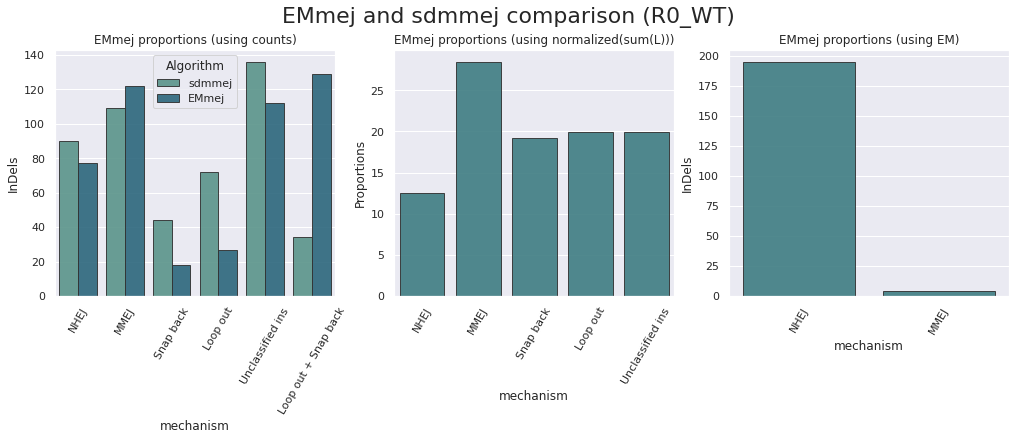

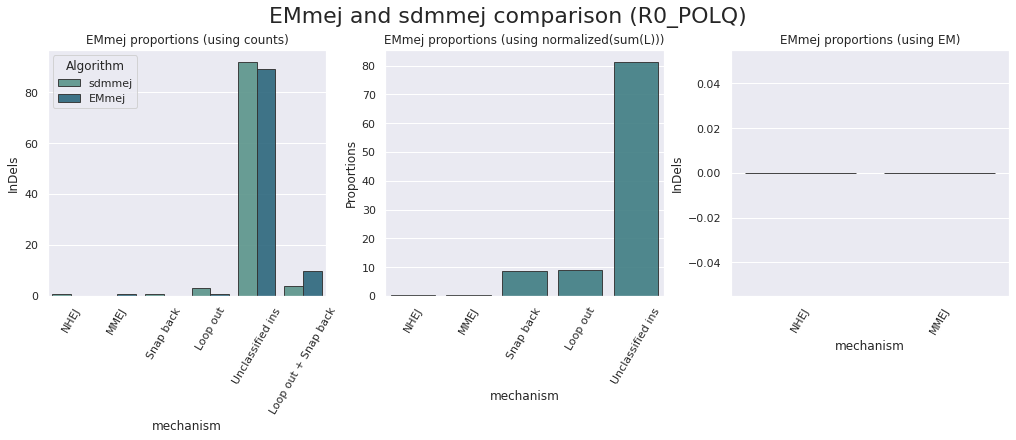

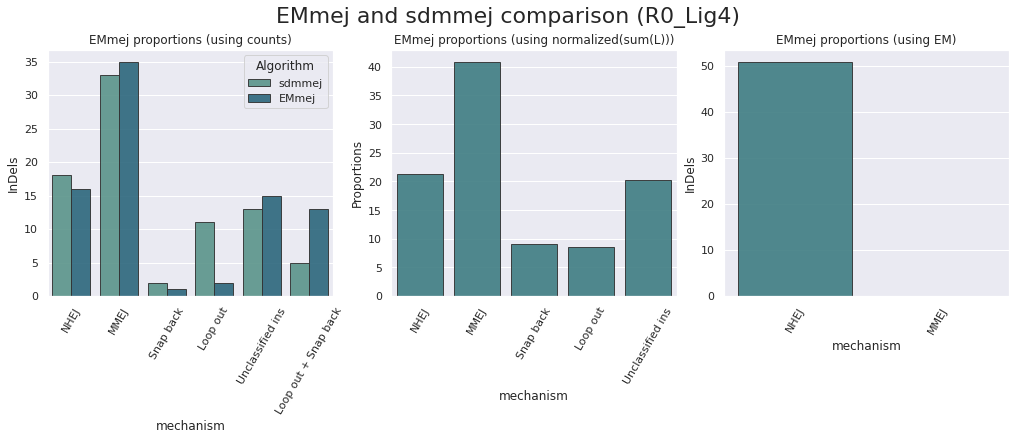

In [337]:
import os

dir = os.path.join(f"{path_to_save_plots}")
if not os.path.exists(dir):
    os.mkdir(dir)

mutants_res_df = pd.DataFrame(columns=['mechanism','indel_type', 'Algorithm', 'InDels','Proportions', 'Mutant'])

for mut in ['R0_WT', 'R0_POLQ', 'R0_Lig4']:
    print(f'-------------- {mut} ---------------')
    EMmej_input_tsv_path = f'/home/labs/alevy/guyta/guy_master_project/results/Drosophila/Terrence_Hanscom_NAR_2022/sdmmej_EMmej_comparison/sdmmej_output_to_EMmej_input/{mut}/20221008/20221008_{mut}_sdmmej_output_EMmej_input.tsv'
    file_prefix = '1737_20221008_20221008'
    RMdetector_output = f'{EMmej_output_path}/{file_prefix}_{mut}_sdmmej_output_EMmej_input_EMmej_run/output_files/RMdetector_output.tsv' 
    ins_repair_proportions = f'{EMmej_output_path}/{file_prefix}_{mut}_sdmmej_output_EMmej_input_EMmej_run/output_files/mechanism_proportion_insertions.tsv' 
    del_repair_proportions = f'{EMmej_output_path}/{file_prefix}_{mut}_sdmmej_output_EMmej_input_EMmej_run/output_files/20221008_EM_log.tsv' 
    path_to_MM_output = f'{EMmej_output_path}/{file_prefix}_{mut}_sdmmej_output_EMmej_input_EMmej_run/output_files/MM_output.tsv' 

    EMmej_input_tsv = pd.read_csv(EMmej_input_tsv_path, sep='\t')

    emmej_res = pd.read_csv(RMdetector_output, sep='\t')
    MM_output = pd.read_csv(path_to_MM_output, sep='\t')
    EMmej_RM_MM = emmej_res.join(MM_output, rsuffix='_MM')
    EMmej_RM_MM.drop(columns = ['CHR_MM', 'POS_MM',
           'original_pos_MM', 'variant_id_MM', 'direction_MM',
           'ancestral_indel_MM', 'derived_indel_MM'], inplace=True)
    EMmej_RM_MM
    # Merging the EMmej and sdmmej results
    emmej_sdmmej_merged = EMmej_RM_MM.merge(EMmej_input_tsv, left_on='CHR', right_on='#CHR')
    emmej_sdmmej_merged.drop(columns=['REF', 'ALT', 'ID'], inplace=True)
    emmej_sdmmej_merged.loc[(emmej_sdmmej_merged['del_mmej'] == True), :].shape
    emmej_sdmmej_merged


    """
    EMmej results: discrete meassuring (counting mechanisms using the boolian indications)
    """
    # Deletions:
    # making a list of cases of which del MMEJ was detected on at list one direction
    mmej = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'DEL') & (emmej_sdmmej_merged['del_mmej'] == True)), 'CHR'].unique().tolist()

    EMmej_nhej = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'DEL') & 
                             (emmej_sdmmej_merged['del_mmej'] == False) & 
                            (~emmej_sdmmej_merged['CHR'].isin(mmej))), :]
    EMmej_nhej_count = EMmej_nhej['CHR'].unique().shape[0]

    EMmej_mmej = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'DEL') & 
                             (emmej_sdmmej_merged['del_mmej'] == True) & 
                            (emmej_sdmmej_merged['CHR'].isin(mmej))), :]
    EMmej_mmej_count = EMmej_mmej['CHR'].unique().shape[0]

    # Insertions
    # Snap back
    snap = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'INS') & (emmej_sdmmej_merged['SD_snap_back'] == True)), 'CHR'].unique().tolist()
    loop = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'INS') & (emmej_sdmmej_merged['SD_loop_out'] == True)), 'CHR'].unique().tolist()
    EMmej_snap = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'INS') & 
                             (emmej_sdmmej_merged['SD_snap_back'] == True) & 
                            (emmej_sdmmej_merged['CHR'].isin(snap))), :]

    EMmej_snap_count = EMmej_snap['CHR'].unique().shape[0]
    EMmej_snap_count = len(parallel(snap,loop))
    # Loop out
    EMmej_loop = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'INS') & 
                             (emmej_sdmmej_merged['SD_loop_out'] == True) & 
                            (emmej_sdmmej_merged['CHR'].isin(loop))), :]
    EMmej_loop_count = EMmej_snap['CHR'].unique().shape[0]
    EMmej_loop_count = len(parallel(loop, snap))

    # SD-MMEJ (Snap + Loop)
    EMmej_snap_loop = pd.concat([EMmej_snap, EMmej_loop], axis=0)
    EMmej_snap_loop_count = EMmej_snap_loop['CHR'].unique().shape[0]
    EMmej_snap_loop_count = len(intersection(snap, loop))

    # Unclassifed insertions
    EMmej_unclassified_ins = emmej_sdmmej_merged.loc[((~emmej_sdmmej_merged['CHR'].isin(EMmej_snap_loop['CHR'].unique())) & (emmej_sdmmej_merged['indel_type'] == 'INS')),:]
    EMmej_unclassified_ins_count = EMmej_unclassified_ins['CHR'].unique().shape[0]

    # Getting EMmej repair mechanisms proportions based on probebalistic model and EM
    # Insertions
    ins_proportions = pd.read_csv(ins_repair_proportions, sep='\t')

    """
    EMmej results: Estimating quantities of each mechanism.
        For deletions: quantities are given by EM estimations * number of deletions
        For insertions: quantities are given by summing the whole lk columns, normalizing them
            to get proportions and then * number of insertions
    """
    # Insertions
    likeliest_ins = get_likelier_mechanism(df=emmej_sdmmej_merged.loc[(emmej_sdmmej_merged['indel_type'] == 'INS'),:])
    EMmej_snap_estimation = likeliest_ins.loc[(likeliest_ins['likeliest_mechanism'] == 'SD_snap_back_lk'),'SD_snap_back_lk'].sum()
    EMmej_loop_estimation = likeliest_ins.loc[(likeliest_ins['likeliest_mechanism'] == 'SD_loop_out_lk'),'SD_loop_out_lk'].sum()
    EMmej_SDMMEJ_estimation = EMmej_snap_estimation + EMmej_loop_estimation
    EMmej_unclassified_ins_estimation = likeliest_ins.loc[(likeliest_ins['likeliest_mechanism'] == 'unclassified_ins_lk'),'unclassified_ins_lk'].sum()

    snap_sum = emmej_sdmmej_merged.loc[(emmej_sdmmej_merged['indel_type'] == 'INS'),'SD_snap_back_lk'].sum()
    loop_sum = emmej_sdmmej_merged.loc[(emmej_sdmmej_merged['indel_type'] == 'INS'),'SD_loop_out_lk'].sum()
    Unclassified_ins_sum = emmej_sdmmej_merged.loc[(emmej_sdmmej_merged['indel_type'] == 'INS'),'unclassified_ins_lk'].sum()
    ins_n = emmej_sdmmej_merged.loc[(emmej_sdmmej_merged['indel_type'] == 'INS'), 'CHR'].unique().shape[0]
    norm_snap_sum = (snap_sum/(snap_sum+loop_sum+Unclassified_ins_sum))*ins_n
    norm_loop_sum = (loop_sum/(snap_sum+loop_sum+Unclassified_ins_sum))*ins_n
    norm_Unclassified_ins_sum = (Unclassified_ins_sum/(snap_sum+loop_sum+Unclassified_ins_sum))*ins_n

    # Deletions using EM
    del_proportions = pd.read_csv(del_repair_proportions, sep='\t')
    EMmej_mmej_proportion = del_proportions.loc[del_proportions.index.max(), 'MMEJ_theta'] * emmej_sdmmej_merged.loc[emmej_sdmmej_merged['indel_type'] == 'DEL', 'CHR'].unique().shape[0]
    EMmej_nhej_proportion = del_proportions.loc[del_proportions.index.max(), 'NHEJ_theta'] * emmej_sdmmej_merged.loc[emmej_sdmmej_merged['indel_type'] == 'DEL', 'CHR'].unique().shape[0]

    # Deletions using sum of lk
    del_n = emmej_sdmmej_merged.loc[emmej_sdmmej_merged['indel_type'] == 'DEL','CHR'].unique().shape[0]
    mmej_lk_sum = emmej_sdmmej_merged.loc[emmej_sdmmej_merged['indel_type'] == 'DEL', 'del_mmej_lk'].sum()
    nhej_lk_sum = emmej_sdmmej_merged.loc[emmej_sdmmej_merged['indel_type'] == 'DEL', 'NHEJ_lk'].sum()
    norm_mmej_lk_sum = (mmej_lk_sum/(mmej_lk_sum+nhej_lk_sum))*del_n
    norm_nhej_lk_sum = (nhej_lk_sum/(mmej_lk_sum+nhej_lk_sum))*del_n

    """
    sdmmej results:
    """
    # Deletions
    sdmmej_Consistent_MHJ_reads = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'DEL') & 
                                                 (emmej_sdmmej_merged['REPAIR_TYPE'] == 'MHJ') &
                                                 (emmej_sdmmej_merged['consistency'] == True)), 'CHR'].unique().shape[0]
    sdmmej_MMEJ_reads = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'DEL') & 
                                                 (emmej_sdmmej_merged['REPAIR_TYPE'] == 'MHJ') &
                                                 (emmej_sdmmej_merged['consistency'] == False)), 'CHR'].unique().shape[0]

    sdmmej_mmej_reads = sdmmej_Consistent_MHJ_reads + sdmmej_MMEJ_reads

    sdmmej_Consistent_ABJ_reads = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'DEL') & 
                                                 (emmej_sdmmej_merged['REPAIR_TYPE'] == 'ABJ') &
                                                 (emmej_sdmmej_merged['consistency'] == True)), 'CHR'].unique().shape[0]
    sdmmej_NHEJ_reads = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'DEL') & 
                                                 (emmej_sdmmej_merged['REPAIR_TYPE'] == 'ABJ') &
                                                 (emmej_sdmmej_merged['consistency'] == False)), 'CHR'].unique().shape[0]

    sdmmej_nhej_abj_reads = sdmmej_Consistent_ABJ_reads + sdmmej_NHEJ_reads

    # Insertions
    emmej_sdmmej_merged['SDMMEJ_snap'] = False
    emmej_sdmmej_merged['SDMMEJ_loop'] = False
    emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['Snap-back'] !='0') & (emmej_sdmmej_merged['Snap-back'].isna() == False)), 'SDMMEJ_snap'] = True
    emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['Loop-out'] !='0') & (emmej_sdmmej_merged['Loop-out'].isna() == False)), 'SDMMEJ_loop'] = True

    SDMMEJ_snap_reads = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['SDMMEJ_snap'] == True) & 
                                                 (emmej_sdmmej_merged['indel_type'] == 'INS')), 'CHR'].unique().shape[0]
    SDMMEJ_loop_reads = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['SDMMEJ_loop'] == True) & 
                                                 (emmej_sdmmej_merged['indel_type'] == 'INS')), 'CHR'].unique().shape[0]


    SDMMEJ_snap = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'INS') & (emmej_sdmmej_merged['SDMMEJ_snap'] == True)), 'CHR'].unique().tolist()
    SDMMEJ_loop = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'INS') & (emmej_sdmmej_merged['SDMMEJ_loop'] == True)), 'CHR'].unique().tolist()
    SDMMEJ_snap_count = len(parallel(SDMMEJ_snap, SDMMEJ_loop))
    SDMMEJ_loop_count = len(parallel(SDMMEJ_loop, SDMMEJ_snap))
    SDMMEJ_loop_and_loop_count = len(intersection(SDMMEJ_loop, SDMMEJ_snap))
    # SDMMEJ_InDels_reads = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['mechanism'] == 'SDMMEJ_InDels') & (emmej_sdmmej_merged['indel_type'] == 'INS')), 'CHR'].unique().shape[0]
    # Other_InDels_reads = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['mechanism'] == 'Other_InDels') & (emmej_sdmmej_merged['indel_type'] == 'INS')), 'CHR'].unique().shape[0]


    indel_n = emmej_sdmmej_merged['CHR'].unique().shape[0]

    mechanism_proportion = pd.DataFrame(columns=['mechanism','indel_type', 'Algorithm', 'InDels','Proportions', 'Mutant'])

    mechanism_proportion.loc[0,:] = 'NHEJ', 'Deletion', 'sdmmej' , sdmmej_nhej_abj_reads, np.nan, mut
    mechanism_proportion.loc[1,:] = 'NHEJ', 'Deletion', 'EMmej' , EMmej_nhej_count, np.nan, mut
    mechanism_proportion.loc[2,:] = 'NHEJ', 'Deletion', 'EMmej proportions estimation (EM)' , EMmej_nhej_proportion, np.nan, mut
    mechanism_proportion.loc[3,:] = 'NHEJ', 'Deletion', 'EMmej proportions estimation (sum(L))' , norm_mmej_lk_sum, (norm_mmej_lk_sum/indel_n)*100, mut

    mechanism_proportion.loc[4,:] = 'MMEJ', 'Deletion', 'sdmmej' , sdmmej_mmej_reads, np.nan, mut
    mechanism_proportion.loc[5,:] = 'MMEJ', 'Deletion', 'EMmej' , EMmej_mmej_count, np.nan, mut
    mechanism_proportion.loc[6,:] = 'MMEJ', 'Deletion', 'EMmej proportions estimation (EM)' , EMmej_mmej_proportion, np.nan, mut
    mechanism_proportion.loc[7,:] = 'MMEJ', 'Deletion', 'EMmej proportions estimation (sum(L))' , norm_nhej_lk_sum, (norm_nhej_lk_sum/indel_n)*100, mut

    # mechanism_proportion.loc[6,:] = 'SDMMEJ_Snap_back', 'Insertion', 'sdmmej' , SDMMEJ_snap_reads
    mechanism_proportion.loc[8,:] = 'Snap back', 'Insertion', 'sdmmej' , SDMMEJ_snap_count, np.nan, mut
    # mechanism_proportion.loc[7,:] = 'SDMMEJ_Snap_back', 'Insertion', 'EMmej', likeliest_ins.loc[likeliest_ins['likeliest_mechanism'] == 'SD_snap_back_lk', 'CHR'].unique().shape[0]
    mechanism_proportion.loc[9,:] = 'Snap back', 'Insertion', 'EMmej', EMmej_snap_count, np.nan, mut
    # mechanism_proportion.loc[8,:] = 'Snap back', 'Insertion', 'EMmej proportions estimation' , EMmej_snap_estimation
    mechanism_proportion.loc[10,:] = 'Snap back', 'Insertion', 'EMmej proportions estimation (sum(L))' , norm_snap_sum, (norm_snap_sum/indel_n)*100, mut


    # mechanism_proportion.loc[9,:] = 'SDMMEJ_Loop_out', 'Insertion', 'sdmmej' , SDMMEJ_loop_reads
    mechanism_proportion.loc[11,:] = 'Loop out', 'Insertion', 'sdmmej' , SDMMEJ_loop_count, np.nan, mut
    # mechanism_proportion.loc[10,:] = 'SDMMEJ_Loop_out', 'Insertion', 'EMmej', likeliest_ins.loc[likeliest_ins['likeliest_mechanism'] == 'SD_loop_out_lk', 'CHR'].unique().shape[0]
    mechanism_proportion.loc[12,:] = 'Loop out', 'Insertion', 'EMmej', EMmej_loop_count, np.nan, mut
    # mechanism_proportion.loc[11,:] = 'Loop out', 'Insertion', 'EMmej proportions estimation' , EMmej_loop_estimation
    mechanism_proportion.loc[13,:] = 'Loop out', 'Insertion', 'EMmej proportions estimation (sum(L))' , norm_loop_sum, (norm_loop_sum/indel_n)*100, mut

    mechanism_proportion.loc[14,:] = 'Unclassified ins', 'Insertion', 'sdmmej' , emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'INS') &
                                                                                                      (~emmej_sdmmej_merged['CHR'].isin(SDMMEJ_snap+SDMMEJ_loop))), 'CHR'].unique().shape[0], np.nan, mut

    mechanism_proportion.loc[15,:] = 'Unclassified ins', 'Insertion', 'EMmej' , emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'INS') & 
                                                                 (~emmej_sdmmej_merged['CHR'].isin(snap+loop))),'CHR'].unique().shape[0], np.nan, mut

    mechanism_proportion.loc[16,:] = 'Unclassified ins', 'Insertion', 'EMmej proportions estimation (sum(L))',  norm_Unclassified_ins_sum, (norm_Unclassified_ins_sum/indel_n)*100, mut


    mechanism_proportion.loc[17,:] = 'Loop out + Snap back', 'Insertion', 'sdmmej' , SDMMEJ_loop_and_loop_count, np.nan, mut
    mechanism_proportion.loc[18,:] = 'Loop out + Snap back', 'Insertion', 'EMmej' , EMmej_snap_loop_count, np.nan, mut
    
    


    print(mechanism_proportion)


    """
    Visualization
    """
    # plt.figure(figsize = (7,5), dpi=80)
    # ax = sns.barplot(data=mechanism_proportion,
    #                  y='InDels', x='mechanism', hue='Algorithm', 
    #                  palette="crest", alpha = 0.9, linewidth=1, edgecolor=".2")
    # ax.set(title='EMmej and sdmmej comparison- R0-WT')
    # plt.xticks(rotation = 45)
    # # plt.text(x=3.55,y=1,s = 'EMmej:\n-MMEJ: MMEJ\n-NHEJ: NHEJ\n-SDMMEJ_InDels: SD-snap back + SD-loop out\n-Other_InDels: Unclassified insertions\n\nsdmmej:\n-MMEJ: MMEJ+Consistent_MHJ\n-NHEJ: NHEJ+Consistent_ABJ\n-SDMMEJ_InDels: SDMMEJ_InDels\n-Other_InDels: Other_InDels')
    # # plt.show()
    # fig = ax.get_figure()

    # fig.savefig(f"{path_to_save_plots}/1141_20221001_EMmej_150bp_sdmmej_comparison_{mut}.svg", bbox_inches='tight')


    fig, (ax1, ax2, ax3) = plt.subplots(1,3,figsize=(14, 6), constrained_layout=True, sharey=False)
    # NHEJ
    fig.suptitle(f'EMmej and sdmmej comparison ({mut})', fontsize=22)

    ax1 = sns.barplot(data=mechanism_proportion.loc[mechanism_proportion['Algorithm'].isin(['sdmmej', 'EMmej']), :],
                     y='InDels', x='mechanism', hue='Algorithm', 
                     palette="crest", alpha = 0.9, linewidth=1, edgecolor=".2", ax=ax1)
    ax1.set(title='EMmej proportions (using counts)')
    ax1.set_xticklabels(
        ax1.get_xticklabels(), 
        rotation=60)

    ax2 = sns.barplot(data=mechanism_proportion.loc[mechanism_proportion['Algorithm'].isin(['EMmej proportions estimation (sum(L))']), :],
                     y='Proportions', x='mechanism', hue='Algorithm', 
                     palette="crest", alpha = 0.9, linewidth=1, edgecolor=".2", ax=ax2)
    ax2.legend([],[], frameon=False)
    ax2.set(title='EMmej proportions (using normalized(sum(L)))')
    ax2.set_xticklabels(
        ax2.get_xticklabels(), 
        rotation=60)
    # ax2 = mechanism_proportion.loc[
    #     mechanism_proportion['Algorithm'].isin(['EMmej proportions estimation (sum(L))']), 
    #     ['Proportions', 'mechanism']].set_index('mechanism').T.plot(kind='bar',
    #                                             stacked=True, width=0.3, ax=ax2)

    # ax2.set_xticklabels(
    #     ax2.get_xticklabels(), 
    #     rotation=60)
    # ax2.set(xlabel=None, ylabel='Proportions [%]')
    # # plt.xticks(color='w')
    # ax2.set(title='EMmej proportions (using normalized(sum(L)))')
    # ax2.legend(bbox_to_anchor=(1, 1))

    ax3 = sns.barplot(data=mechanism_proportion.loc[mechanism_proportion['Algorithm'].isin(['EMmej proportions estimation (EM)']), :],
                     y='InDels', x='mechanism', hue='Algorithm', 
                     palette="crest", alpha = 0.9, linewidth=1, edgecolor=".2", ax=ax3)
    ax3.legend([],[], frameon=False)
    ax3.set(title='EMmej proportions (using EM)')
    ax3.set_xticklabels(
        ax3.get_xticklabels(), 
        rotation=60)
    
    mutants_res_df = pd.concat([mutants_res_df, mechanism_proportion])
    

#     fig.savefig(f"{path_to_save_plots}/{file_prefix}_EMmej_150bp_sdmmej_comparison_{mut}.svg", bbox_inches='tight')
#     mechanism_proportion.to_csv(f"{path_to_save_plots}/{file_prefix}_EMmej_150bp_sdmmej_comparison_{mut}_data.tsv", 
#                                 sep='\t')


In [338]:
mechanism_proportion.loc[((mechanism_proportion['indel_type'] == 'Insertion') & (mechanism_proportion['Algorithm'] == 'sdmmej')), :].sum()
mechanism_proportion.loc[((mechanism_proportion['indel_type'] == 'Insertion') & (mechanism_proportion['Algorithm'] == 'EMmej')), :].sum()
mutants_res_df

,mechanism,indel_type,Algorithm,InDels,Proportions,Mutant
0,NHEJ,Deletion,sdmmej,90,NaN,R0_WT
1,NHEJ,Deletion,EMmej,77,NaN,R0_WT
2,NHEJ,Deletion,EMmej proportions estimation (EM),195.103124,NaN,R0_WT
3,NHEJ,Deletion,EMmej proportions estimation (sum(L)),60.903912,12.557508,R0_WT
4,MMEJ,Deletion,sdmmej,109,NaN,R0_WT
5,MMEJ,Deletion,EMmej,122,NaN,R0_WT
6,MMEJ,Deletion,EMmej proportions estimation (EM),3.896876,NaN,R0_WT
7,MMEJ,Deletion,EMmej proportions estimation (sum(L)),138.096088,28.47342,R0_WT
8,Snap back,Insertion,sdmmej,44,NaN,R0_WT
9,Snap back,Insertion,EMmej,18,NaN,R0_WT


In [342]:
mutants_res_df.loc[mutants_res_df['Algorithm'].isin(['EMmej']), :]

,mechanism,indel_type,Algorithm,InDels,Proportions,Mutant
1,NHEJ,Deletion,EMmej,77,NaN,R0_WT
5,MMEJ,Deletion,EMmej,122,NaN,R0_WT
9,Snap back,Insertion,EMmej,18,NaN,R0_WT
12,Loop out,Insertion,EMmej,27,NaN,R0_WT
15,Unclassified ins,Insertion,EMmej,112,NaN,R0_WT
18,Loop out + Snap back,Insertion,EMmej,129,NaN,R0_WT
1,NHEJ,Deletion,EMmej,0,NaN,R0_POLQ
5,MMEJ,Deletion,EMmej,1,NaN,R0_POLQ
9,Snap back,Insertion,EMmej,0,NaN,R0_POLQ
12,Loop out,Insertion,EMmej,1,NaN,R0_POLQ


[Text(0, 0, 'NHEJ'), Text(1, 0, 'MMEJ')]

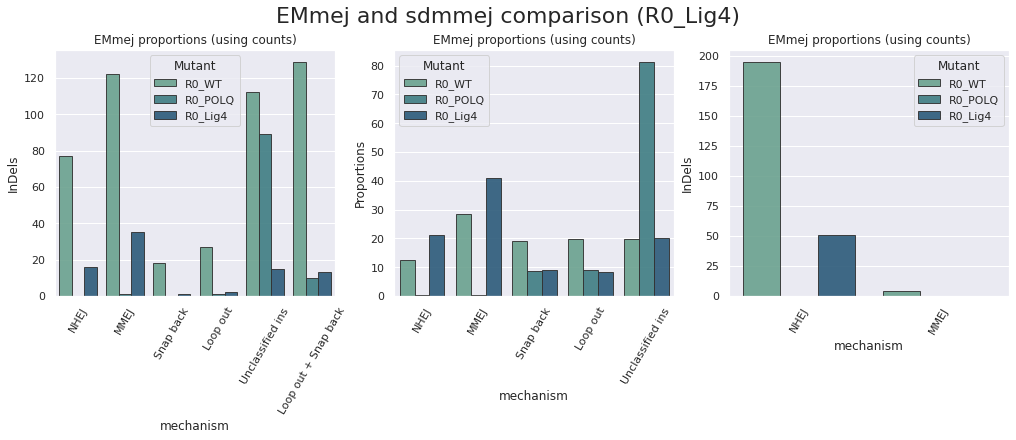

In [373]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3,figsize=(14, 6), constrained_layout=True, sharey=False)
# NHEJ
fig.suptitle(f'EMmej and sdmmej comparison ({mut})', fontsize=22)

ax1 = sns.barplot(data=mutants_res_df.loc[mutants_res_df['Algorithm'].isin(['EMmej']), :],
                 y='InDels', x='mechanism', hue='Mutant', 
                 palette="crest", alpha = 0.9, linewidth=1, edgecolor=".2", ax=ax1)
ax1.set(title='EMmej proportions (using counts)')
ax1.set_xticklabels(
    ax1.get_xticklabels(), 
    rotation=60)

ax2 = sns.barplot(data=mutants_res_df.loc[mutants_res_df['Algorithm'].isin(['EMmej proportions estimation (sum(L))']), :],
                 y='Proportions', x='mechanism', hue='Mutant', 
                 palette="crest", alpha = 0.9, linewidth=1, edgecolor=".2", ax=ax2)
ax2.set(title='EMmej proportions (using counts)')
ax2.set_xticklabels(
    ax2.get_xticklabels(), 
    rotation=60)

ax3 = sns.barplot(data=mutants_res_df.loc[mutants_res_df['Algorithm'].isin(['EMmej proportions estimation (EM)']), :],
                 y='InDels', x='mechanism', hue='Mutant', 
                 palette="crest", alpha = 0.9, linewidth=1, edgecolor=".2", ax=ax3)
ax3.set(title='EMmej proportions (using counts)')
ax3.set_xticklabels(
    ax3.get_xticklabels(), 
    rotation=60)

In [333]:
emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type']=='INS') & 
                        (emmej_sdmmej_merged['SD_snap_back'] == False) &
                        (emmej_sdmmej_merged['SD_snap_back'] == False)),'CHR'].unique().shape[0]


snap = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'INS') & (emmej_sdmmej_merged['SD_snap_back'] == True)), 'CHR'].unique().tolist()
loop = emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'INS') & (emmej_sdmmej_merged['SD_loop_out'] == True)), 'CHR'].unique().tolist()


print(len(intersection(snap,loop)))
print(len(intersection(loop,snap)))


a = parallel(snap, loop)
b = parallel(loop, snap)
print(len(a))
len(b)
129+27+18



13
13
1


99.99999999999999

In [350]:

from io import StringIO
from MicroHomology_module_v3 import MicroHomology
x = emmej_sdmmej_merged.loc[emmej_sdmmej_merged['CHR'] == 'Iw7_D_0', :]
x
idx=346
ex = MicroHomology(indel_sequence=emmej_sdmmej_merged.loc[idx, :]['derived_indel'], # change name to derived seq
                            ancestral_sequence=emmej_sdmmej_merged.loc[idx, :]['ancestral_indel'],
                            pos_on_chr=emmej_sdmmej_merged.loc[idx, :]['POS_x'],
                            indel_type=emmej_sdmmej_merged.loc[idx, :]['indel_type'],
                            flip=False,
                            include_context=True,
                            windowsize=80, refFA=refFA, chr=emmej_sdmmej_merged.loc[idx, :]['CHR'])

# CGTCGTTTAGAGCAGCAGCCGAATTCGGTACATTACCCTGTTATCCCTAGCGGC
ex.ex_data

TAATCGTCACCTGCAGGAAGGTTTAAACGCATTTAGGTGACACTATAGAAGTGTGTATCGCTCGAGGGATCCGAATTCAGGAGGTAAAAACCATGATGGAGGGAAAAAATTCGTACTTTGGAGTACGAAATGC
GTCGTTTAGAGCAGCAGCCGAATTCGGTACATTACCCTGTTATCCCTAGCGGCCGCATAGGCCACTAGTGGATCTGGATCCTCTAGAGTCGACCTCGAACGTTAACGTTAACGTAACGTTAACTCGAGGCCCTG


,del_mmej,del_mmej_cand,del_mmej_marked,del_mmej_marked_on_ref,del_last_dimer,del_mmej_cand_len,SD_snap_back,snap_mmej_marked,snap_P1,snap_P2,snap_mh1,snap_mh2,snap_repeat_pat,snap_inv_comp_repeat_pat,snap_last_dimer,snap_dist_between_reps,SD_loop_out,loop_mmej_marked,loop_P2,loop_mh2,loop_repeat_pat,loop_last_dimer,loop_dist_between_reps,ref_genome_context,accession_sequence
0,True,GC,AGTACGAAAT*[GC]*CGCATAGGCC,AGTACGAAAT*[GC]*|GTCGTTTAGAGCAGCAGCCGAATTCGGTACATTACCCTGTTATCCCTAGCG*[GC]*CGCATAGGCCA,GC,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TAATCGTCACCTGCAGGAAGGTTTAAACGCATTTAGGTGACACTATAGAAGTGTGTATCGCTCGAGGGATCCGAATTCAGGAGGTAAAAACCATGATGGAGGGAAAAAATTCGTACTTTGGAGTACGAAATGCGTCGTTTAGAGCAGCAGCCGAATTCGGTACATTACCCTGTTATCCCTAGCGGCCGCATAGGCCACTAGTGGATCTGGATCCTCTAGAGTCGACCTCGAACGTTAACGTTAACGTAACGTTAACTCGAGGCCCTG,TAATCGTCACCTGCAGGAAGGTTTAAACGCATTTAGGTGACACTATAGAAGTGTGTATCGCTCGAGGGATCCGAATTCAGGAGGTAAAAACCATGATGGAGGGAAAAAATTCGTACTTTGGAGTACGAAATGCCGCATAGGCCACTAGTGGATCTGGATCCTCTAGAGTCGACCTCGAACGTTAACGTTAACGTAACGTTAACTCGAGGCCCTG


In [372]:
emmej_sdmmej_merged.loc[emmej_sdmmej_merged['CHR'] == 'Iw7_D_0', :]
# GTCGTTTAGAGCAGCAGCCGAATTCGGTACATTACCCTGTTATCCCTAGCGGC
ref
emmej_sdmmej_merged.loc[((emmej_sdmmej_merged['indel_type'] == 'INS') & (emmej_sdmmej_merged['indel_len'] > 15)),: ]
# emmej_sdmmej_merged.loc[emmej_sdmmej_merged['CHR'] == 'Iw7_CI_8', :]

,CHR,POS_x,original_pos,variant_id,direction,ancestral_indel,derived_indel,indel_type,indel_len,del_mmej,del_mmej_cand,del_mmej_marked,del_mmej_marked_on_ref,del_last_dimer,del_mmej_cand_len,SD_snap_back,snap_mmej_marked,snap_P1,snap_P2,snap_mh1,snap_mh2,snap_repeat_pat,snap_inv_comp_repeat_pat,snap_last_dimer,snap_dist_between_reps,SD_loop_out,loop_mmej_marked,loop_P2,loop_mh2,loop_repeat_pat,loop_last_dimer,loop_dist_between_reps,del_mmej_lk,del_mmej_p_val,SD_snap_back_lk,SD_snap_back_p_val,SD_loop_out_lk,SD_loop_out_p_val,NHEJ_lk,NHEJ_p_val,unclassified_ins_lk,unclassified_ins_p_val,indel_len_MM,del_mmej_cand_MM,del_mmej_cand_len_MM,#CHR,POS_y,RECONSTRUCTED_SEQ,del_seq,REPAIR_TYPE,consistency,CLASS,CLASS_final,READS,MICROHOMOLOGY,MH_Length,LEFT_DEL_INDEX,RIGHT_DEL_INDEX,left_del,right_del,DRmotif_length,RCmotif_length,Loop-out,Snap-back,SDMMEJ_snap,SDMMEJ_loop
98,Iw7_CI_142,1082,1082,Iw7_CI_142_1082,0,C,CTAGCGGCCGCATAGGCCACTAGTGGATCTA,INS,30.0,False,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,30,NaN,NaN,Iw7_CI_142,1082,GATCCTAGGATCCTAGGATCCTAGGATCCTAGGATCCTAGGATCCTAGGATCCTAGGATCCTAGGATCCTAGGATCCTAGGAGGGAAAAAATTCGTACTTTGGAGTACGAAATGCGTCGTTTAGAGCAGCAGCCGAATTCGGTACATTACCCTGTTATCCCTAGCGGCCGCATAGGCCACTAGTGGATCTAGATCCTCTAGAGTCGACCTCGAACGTTAACGTTAACGTAACGTTAACTCGAGGCCCAGGACCCCAGGACCCCAGGACCCCAGGACCCCAGGACCCCAGGACCCCAGGACCCCAGGACCCCAGGACCCCAGGACC,GATCCTAGGATCCTAGGATCCTAGGATCCTAGGATCCTAGGATCCTAGGATCCTAGGATCCTAGGATCCTAGGATCCTAGGAGGGAAAAAATTCGTACTTTGGAGTACGAAATGCGTCGTTTAGAGCAGCAGCCGAATTCGGTACATTACCCTGTTATCCCGATCCTCTAGAGTCGACCTCGAACGTTAACGTTAACGTAACGTTAACTCGAGGCCCAGGACCCCAGGACCCCAGGACCCCAGGACCCCAGGACCCCAGGACCCCAGGACCCCAGGACCCCAGGACCCCAGGACC,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,161.0,192.0,NaN,NaN,0,0,False,False
99,Iw7_CI_142,1082,1082,Iw7_CI_142_1082,1,C,CTAGCGGCCGCATAGGCCACTAGTGGATCTA,INS,30.0,False,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,30,NaN,NaN,Iw7_CI_142,1082,GATCCTAGGATCCTAGGATCCTAGGATCCTAGGATCCTAGGATCCTAGGATCCTAGGATCCTAGGATCCTAGGATCCTAGGAGGGAAAAAATTCGTACTTTGGAGTACGAAATGCGTCGTTTAGAGCAGCAGCCGAATTCGGTACATTACCCTGTTATCCCTAGCGGCCGCATAGGCCACTAGTGGATCTAGATCCTCTAGAGTCGACCTCGAACGTTAACGTTAACGTAACGTTAACTCGAGGCCCAGGACCCCAGGACCCCAGGACCCCAGGACCCCAGGACCCCAGGACCCCAGGACCCCAGGACCCCAGGACCCCAGGACC,GATCCTAGGATCCTAGGATCCTAGGATCCTAGGATCCTAGGATCCTAGGATCCTAGGATCCTAGGATCCTAGGATCCTAGGAGGGAAAAAATTCGTACTTTGGAGTACGAAATGCGTCGTTTAGAGCAGCAGCCGAATTCGGTACATTACCCTGTTATCCCGATCCTCTAGAGTCGACCTCGAACGTTAACGTTAACGTAACGTTAACTCGAGGCCCAGGACCCCAGGACCCCAGGACCCCAGGACCCCAGGACCCCAGGACCCCAGGACCCCAGGACCCCAGGACCCCAGGACC,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,161.0,192.0,NaN,NaN,0,0,False,False
250,Iw7_CI_56,1082,1082,Iw7_CI_56_1082,0,C,CTAGCGGCCGCATAGGCCACTAGTGGATCTT,INS,30.0,False,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,30,NaN,NaN,Iw7_CI_56,1082,GATCCTAGGATCCTAGGATCCTAGGATCCTAGGATCCTAGGATCCTAGGATCCTAGGATCCTAGGATCCTAGGATCCTAGGAGGGAAAAAATTCGTACTTTGGAGTACGAAATGCGTCGTTTAGAGCAGCAGCCGAATTCGGTACATTACCCTGTTATCCCTAGCGGCCGCATAGGCCACTAGTGGATCTTGATCCTCTAGAGTCGACCTCGAACGTTAACGTTAACGTAACGTTAACTCGAGGCCCAGGACCCCAGGACCCCAGGACCCCAGGACCCCAGGACCCCAGGACCCCAGGACCCCAGGACCCCAGGACCCCAGGACC,GATCCTAGGATCCTAGGATCCTAGGATCCTAGGATCCTAGGATCCTAGGATCCTAGGATCCTAGGATCCTAGGATCCTAGGAGGGAAAAAATTCGTACTTTGGAGTACGAAATGCGTCGTTTAGAGCAGCAGCCGAATTCGGTACATTACCCTGTTATCCCGATCCTCTAGAGTCGACCTCGAACGTTAACGTTAACGTAACGTTAACTCGAGGCCCAGGACCCCAGGACCCCAGGACCCCAGGACCCCAGGACCCCAGGACCCCAGGACCCCAGGACCCCAGGACCCCAGGACC,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,161.0,192.0,NaN,NaN,0,0,False,False
251,Iw7_CI_56,1082,1082,Iw7_CI_56_1082,1,C,CTAGCGGCCGCATAGGCCACTAGTGGATCTT,INS,30.0,False,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,30,NaN,NaN,Iw7_CI_56,1082,GATCCTAGGATCCTAGGATCCTAGGATCCTAGGATCCTAG

In [353]:
ref


'GATCCTAGGATCCTAGGATCCTAGGATCCTAGGATCCTAGGATCCTAGGATCCTAGGATCCTAGGATCCTAGGATCCTAGGAGGGAAAAAATTCGTACTTTGGAGTACGAAATGCGTCGTTTAGAGCAGCAGCCGAATTCGGTACATTACCCTGTTATCCCTAGCGGCCGCATAGGCCACTAGTGGATCTGGATCCTCTAGAGTCGACCTCGAACGTTAACGTTAACGTAACGTTAACTCGAGGCCCAGGACCCCAGGACCCCAGGACCCCAGGACCCCAGGACCCCAGGACCCCAGGACCCCAGGACCCCAGGACCCCAGGACC'

$formula:total\;likelihood=\Sigma_{x=1} ^{x=d} L_R$